# Data Exploration and Visualization

## Loading Prerequisites

In [1]:
# Install updated version of ydata_profiling.
# You only need to do this if you want to use this package.
# You have to run it everytime you load the notebook. This may take a few minutes.
!pip install -U ydata-profiling


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=50b987246ab97391d0141fdde9c94142fe081eef6d114c697e7971f5330a1664
  Stored in directory: /root/.cache/pip/wheels/5f/d4/d7/4189b07b5902ee9f3ce0dbb14909fbe8037c39d6c63ffd49c9
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
     

In [64]:
## Importing python packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from itertools import product
import warnings
from ydata_profiling import ProfileReport


In [65]:
## Some configuration

%matplotlib inline

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

# Set seaborn style
sns.set()

# hide warnings
warnings.filterwarnings("ignore")

## Loading Data

In [4]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [9]:
## Load csv file into a dataframe
## Alternative location of the csv file
# If you can't use the code above because of the file location
# in your drive, use the link below:

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"
## df = pd.read_csv(data_path)

In [10]:
df

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8993,8993,1960,94367.0,28,1,896,68,5,21,3,4,1.0,55,F,1st Cycle,Single,Take my money!!
8994,8994,1975,58121.0,12,6,61,53,6,28,7,6,1.0,71,M,2nd Cycle,Single,Meh...
8995,8995,1986,54292.0,29,72,1011,41,11,36,1,11,0.0,31,M,Graduation,Together,Take my money!!
8996,8996,1938,125962.0,38,75,1668,61,2,25,5,6,1.0,45,M,2nd Cycle,Married,Take my money!!


### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Initial Analysis

In [11]:
## Look at the first 10 rows of the data
df.head(10)

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!
5,5,1982,22386.0,14,65,56,47,2,48,2,1,1.0,67,M,PhD,Single,OK nice!
6,6,1969,69485.0,18,73,345,71,7,13,1,8,1.0,46,M,Graduation,Together,OK nice!
7,7,1960,68602.0,5,44,41,84,1,12,2,0,1.0,37,M,Graduation,Together,Horrible
8,8,1940,109499.0,30,75,1401,38,9,35,9,9,0.0,17,M,Graduation,Divorced,OK nice!
9,9,1994,23846.0,8,153,19,18,55,17,10,1,1.0,39,F,1st Cycle,Together,Meh...


In [12]:
## What if we only want to see the first 5 rows?
df.head(5)

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!


In [13]:
## What if we want to see the LAST rows?
df.tail(10)

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
8988,8988,1947,100928.0,28,6,1152,74,3,20,1,2,0.0,29,F,Master,Divorced,Take my money!!
8989,8989,1947,87605.0,21,18,823,34,21,9,35,1,0.0,9,M,1st Cycle,Widow,Kind of OK
8990,8990,1995,28144.0,10,41,46,11,40,24,22,2,1.0,59,M,1st Cycle,Married,OK nice!
8991,8991,1939,126254.0,46,36,2231,32,4,47,9,8,0.0,22,M,Graduation,Divorced,Take my money!!
8992,8992,1954,87399.0,25,1,837,56,8,27,8,1,NaN,47,M,Graduation,Married,Kind of OK
8993,8993,1960,94367.0,28,1,896,68,5,21,3,4,1.0,55,F,1st Cycle,Single,Take my money!!
8994,8994,1975,58121.0,12,6,61,53,6,28,7,6,1.0,71,M,2nd Cycle,Single,Meh...
8995,8995,1986,54292.0,29,72,1011,41,11,36,1,11,0.0,31,M,Graduation,Together,Take my money!!
8996,8996,1938,125962.0,38,75,1668,61,2,25,5,6,1.0,45,M,2nd Cycle,Married,Take my money!!
8997,8997,1994,26385.0,9,24,46,5,13,21,46,15,1.0,52,M,1st Cycle,Single,Kind of OK


In [14]:
## Look at dataset data types
df.dtypes

,0
Unnamed: 0,int64
age,int64
income,float64
frq,int64
rcn,int64
mnt,int64
clothes,int64
kitchen,int64
small_appliances,int64
toys,int64


In [15]:
## Count of missing values
df.isna().sum()

,0
Unnamed: 0,0
age,0
income,46
frq,0
rcn,0
mnt,0
clothes,0
kitchen,0
small_appliances,0
toys,0


In [16]:
## Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [17]:
## Check descriptive statistics: Numeric features only
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,8998.0,4498.500000,2597.643195,0.0,2249.25,4498.5,6747.75,8997.0
age,8998.0,1966.059680,17.296552,1936.0,1951.00,1966.0,1981.00,1996.0
income,8952.0,69963.550827,27591.556226,10000.0,47741.00,70030.5,92218.00,140628.0
frq,8998.0,19.848077,10.903435,3.0,10.00,17.0,28.00,59.0
rcn,8998.0,62.469771,69.761802,0.0,26.00,53.0,79.00,549.0
mnt,8998.0,622.162814,646.768205,6.0,63.00,383.0,1076.00,3052.0
clothes,8998.0,50.446655,23.422249,1.0,33.00,51.0,69.00,99.0
kitchen,8998.0,7.039675,7.848139,0.0,2.00,4.0,10.00,75.0
small_appliances,8998.0,28.524116,12.586437,1.0,19.00,28.0,37.00,74.0
toys,8998.0,7.036897,7.924422,0.0,2.00,4.0,10.00,62.0


In [18]:
## Check descriptive statistics: All features
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,8998.0,NaN,NaN,NaN,4498.5,2597.643195,0.0,2249.25,4498.5,6747.75,8997.0
age,8998.0,NaN,NaN,NaN,1966.05968,17.296552,1936.0,1951.0,1966.0,1981.0,1996.0
income,8952.0,NaN,NaN,NaN,69963.550827,27591.556226,10000.0,47741.0,70030.5,92218.0,140628.0
frq,8998.0,NaN,NaN,NaN,19.848077,10.903435,3.0,10.0,17.0,28.0,59.0
rcn,8998.0,NaN,NaN,NaN,62.469771,69.761802,0.0,26.0,53.0,79.0,549.0
mnt,8998.0,NaN,NaN,NaN,622.162814,646.768205,6.0,63.0,383.0,1076.0,3052.0
clothes,8998.0,NaN,NaN,NaN,50.446655,23.422249,1.0,33.0,51.0,69.0,99.0
kitchen,8998.0,NaN,NaN,NaN,7.039675,7.848139,0.0,2.0,4.0,10.0,75.0
small_appliances,8998.0,NaN,NaN,NaN,28.524116,12.586437,1.0,19.0,28.0,37.0,74.0
toys,8998.0,NaN,NaN,NaN,7.036897,7.924422,0.0,2.0,4.0,10.0,62.0


In [ ]:
## Notice the NaN values. Why do you think we get these?

In [19]:
## Get unique values in a column
df['education'].unique()

array(['Graduation', 'PhD', 'Master', '1st Cycle', '2nd Cycle',
       'OldSchool', nan], dtype=object)

In [20]:
## Fix wrong data types
df.dependents = df.dependents.astype("boolean")

In [ ]:
## TIP
# Different ways to access the values of a column

# df.age
# df['age']

## Which way do you think is more flexible?

In [21]:
## See all the column names
df.columns

Index(['Unnamed: 0', 'age', 'income', 'frq', 'rcn', 'mnt', 'clothes',
       'kitchen', 'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description'],
      dtype='object')

In [22]:
# Split features into metric/numeric vs non-metric/non-numeric

non_metric_features = ["education", "status", "gender", "dependents", "description"]

metric_features = ['age', 'income', 'frq', 'rcn', 'mnt',
 'clothes', 'kitchen', 'small_appliances', 'toys', 'house_keeping', 'per_net_purchase']


## Visual Exploration

Matplotlib tutorials: https://matplotlib.org/stable/tutorials/index.html

Matplotlib gallery: https://matplotlib.org/stable/gallery/index

Seaborn tutorials: https://seaborn.pydata.org/tutorial.html


Seaborn gallery: https://seaborn.pydata.org/examples/index.html

**More examples for visualizing distributions:**
- http://seaborn.pydata.org/tutorial/distributions.html


### Univariate Distribution

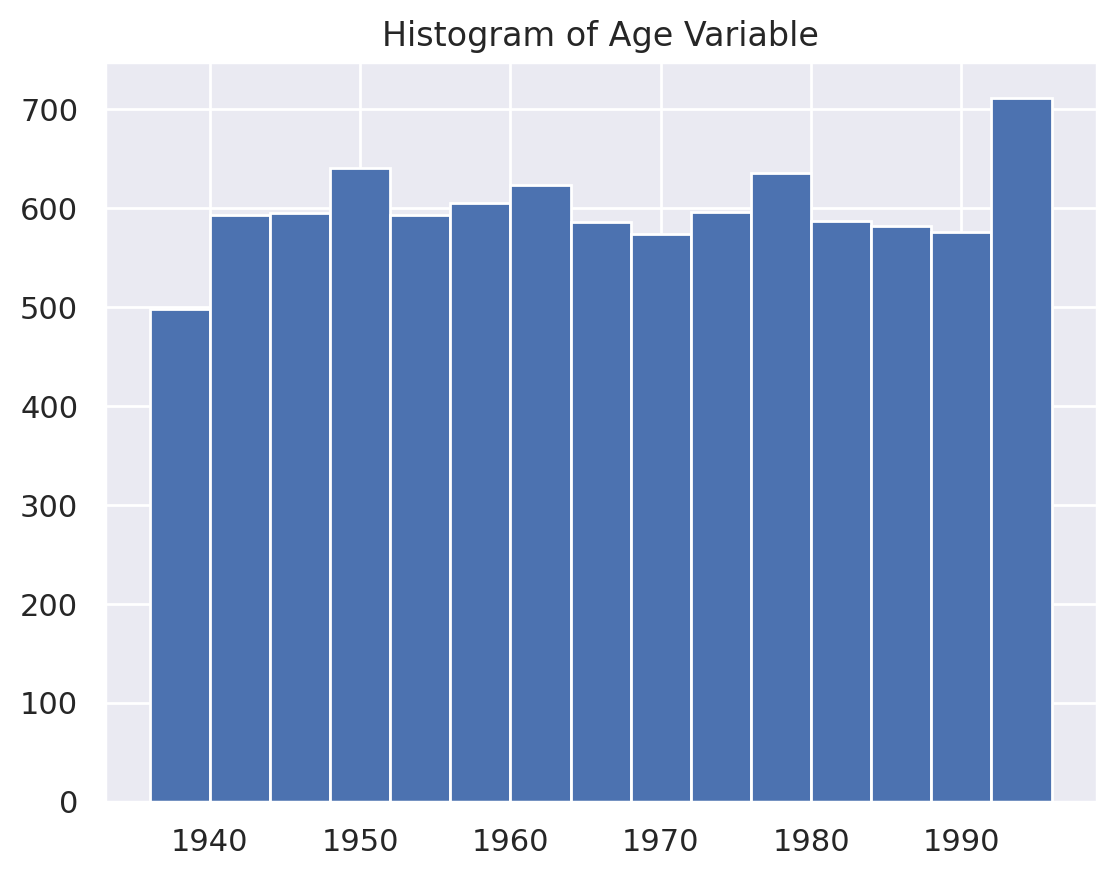

In [23]:
# Single Metric Variable Histogram

plt.hist(df["age"], bins=15)  # mess around with the bins

# Set the title of the plot
plt.title("Histogram of Age Variable")

# Show the plot
plt.show()

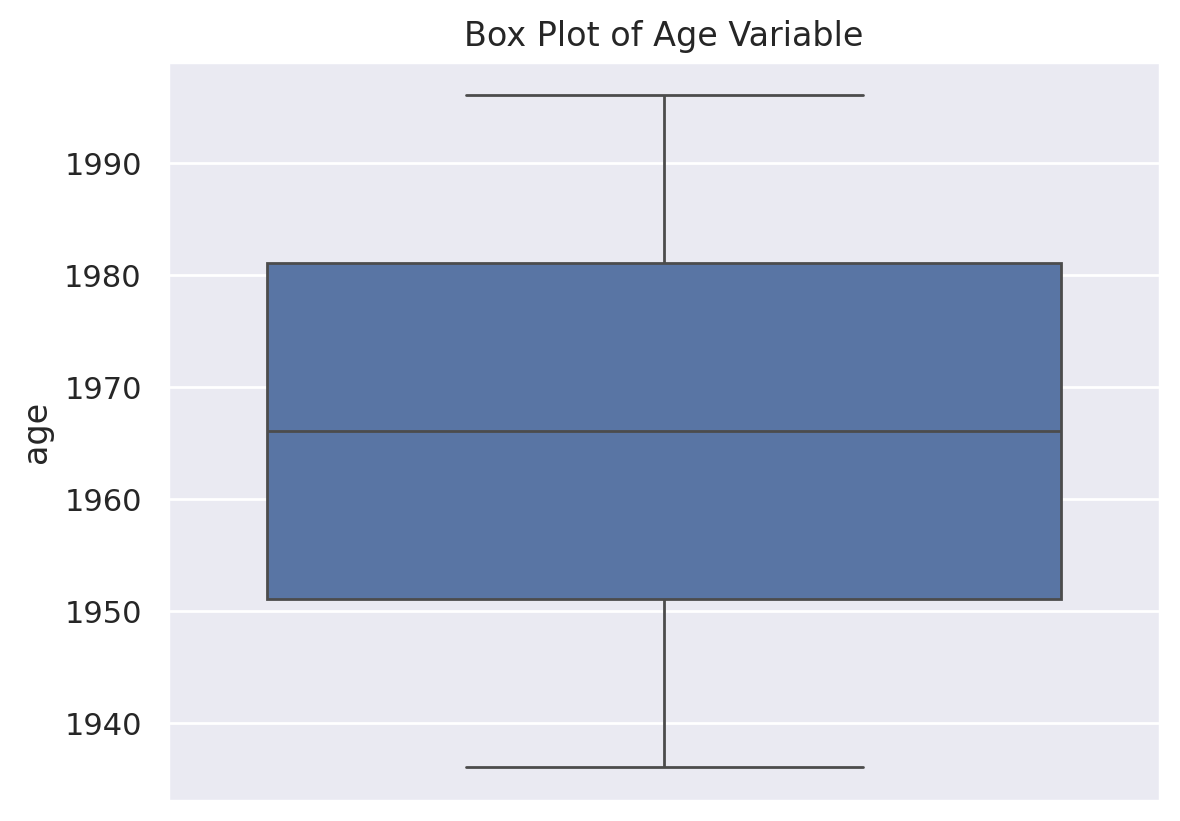

In [24]:
# Single Metric Variable Box Plot
sns.boxplot(y=df["age"])
plt.title("Box Plot of Age Variable")
plt.show()

In [25]:
## Define a function that plots multiple histograms

def plot_multiple_histograms(data, feats, title="Numeric Variables' Histograms", figsize=(18, 8)):

    # Prepare figure. Create individual axes where each histogram will be placed
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)

    # Plot data
    # Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
    for ax, feat in zip(axes.flatten(), feats): # Notice the zip() function and flatten() method
      ax.hist(data[feat])
      ax.set_title(feat)

    # Layout
    # Add a centered title to the figure:
    plt.suptitle(title)

    plt.show()

    return


## Define a function that plots multiple box plots

def plot_multiple_boxplots(data, feats, title="Numeric Variables' Box Plots", figsize=(18, 8)):

    # Prepare figure. Create individual axes where each histogram will be placed
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)

    # Plot data
    # Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
    for ax, feat in zip(axes.flatten(), feats): # Notice the zip() function and flatten() method
      sns.boxplot(x=data[feat], ax=ax)
      ax.set_title(feat)
      ax.set_xlabel("")


    # Layout
    # Add a centered title to the figure:
    plt.suptitle(title)

    plt.show()

    return




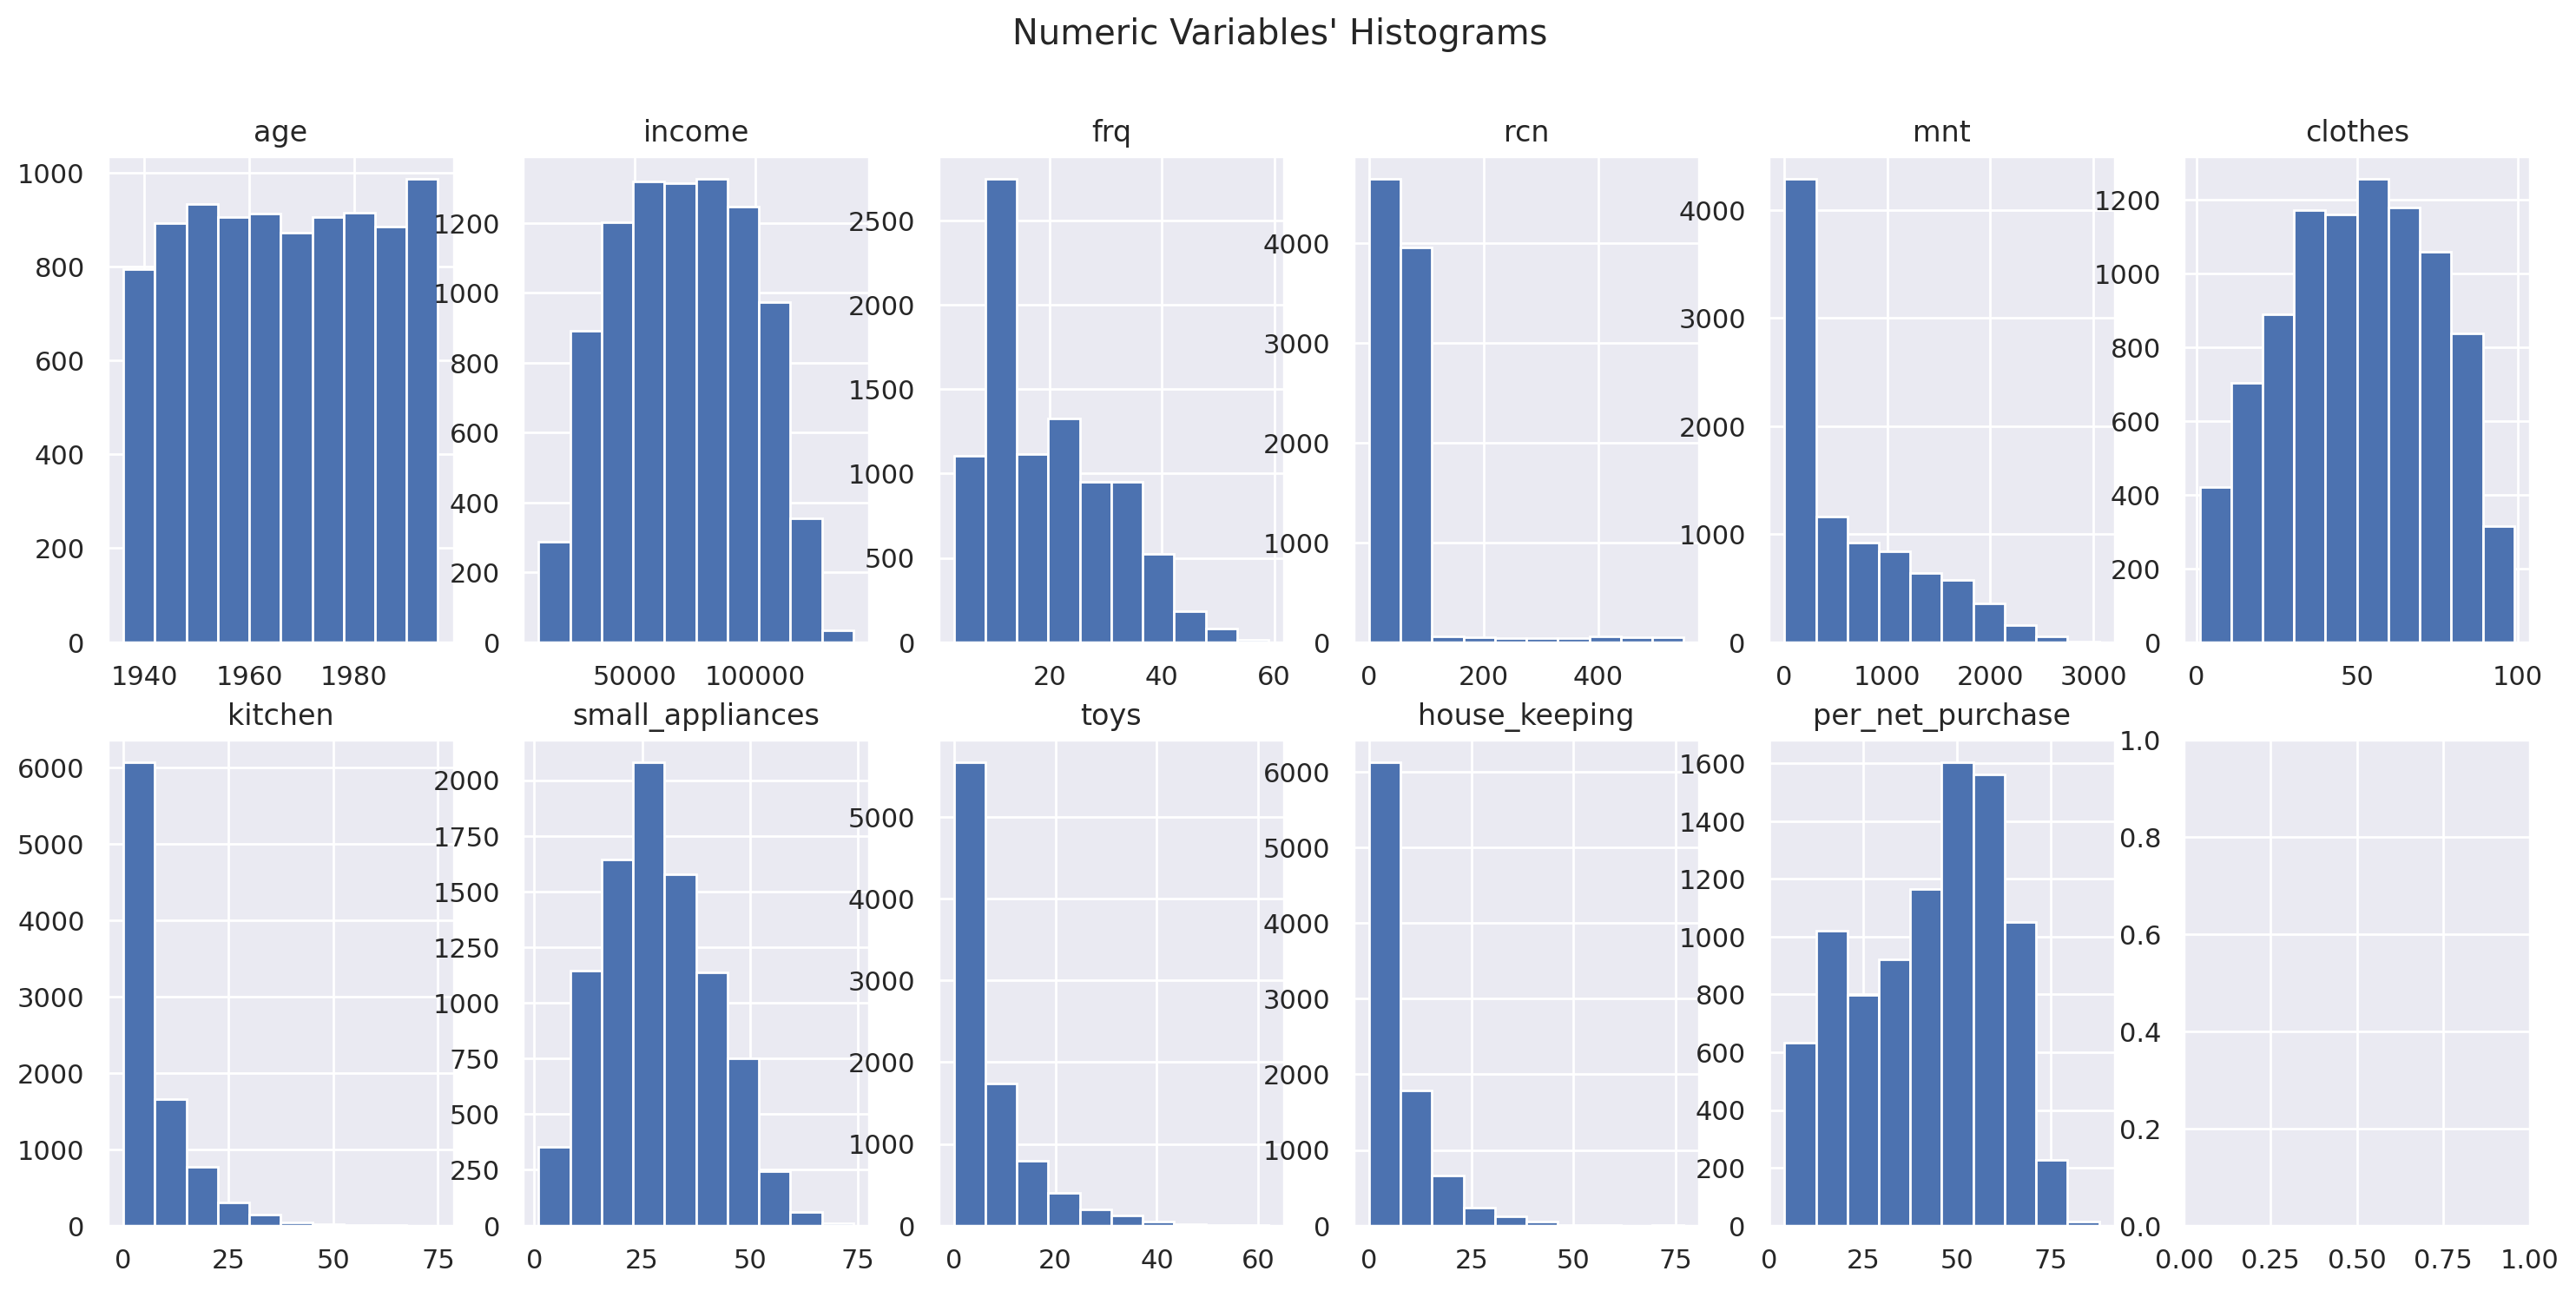

In [26]:
# All Numeric Variables' Histograms in one figure

# set the default styles
sns.set()

plot_multiple_histograms(df, metric_features)



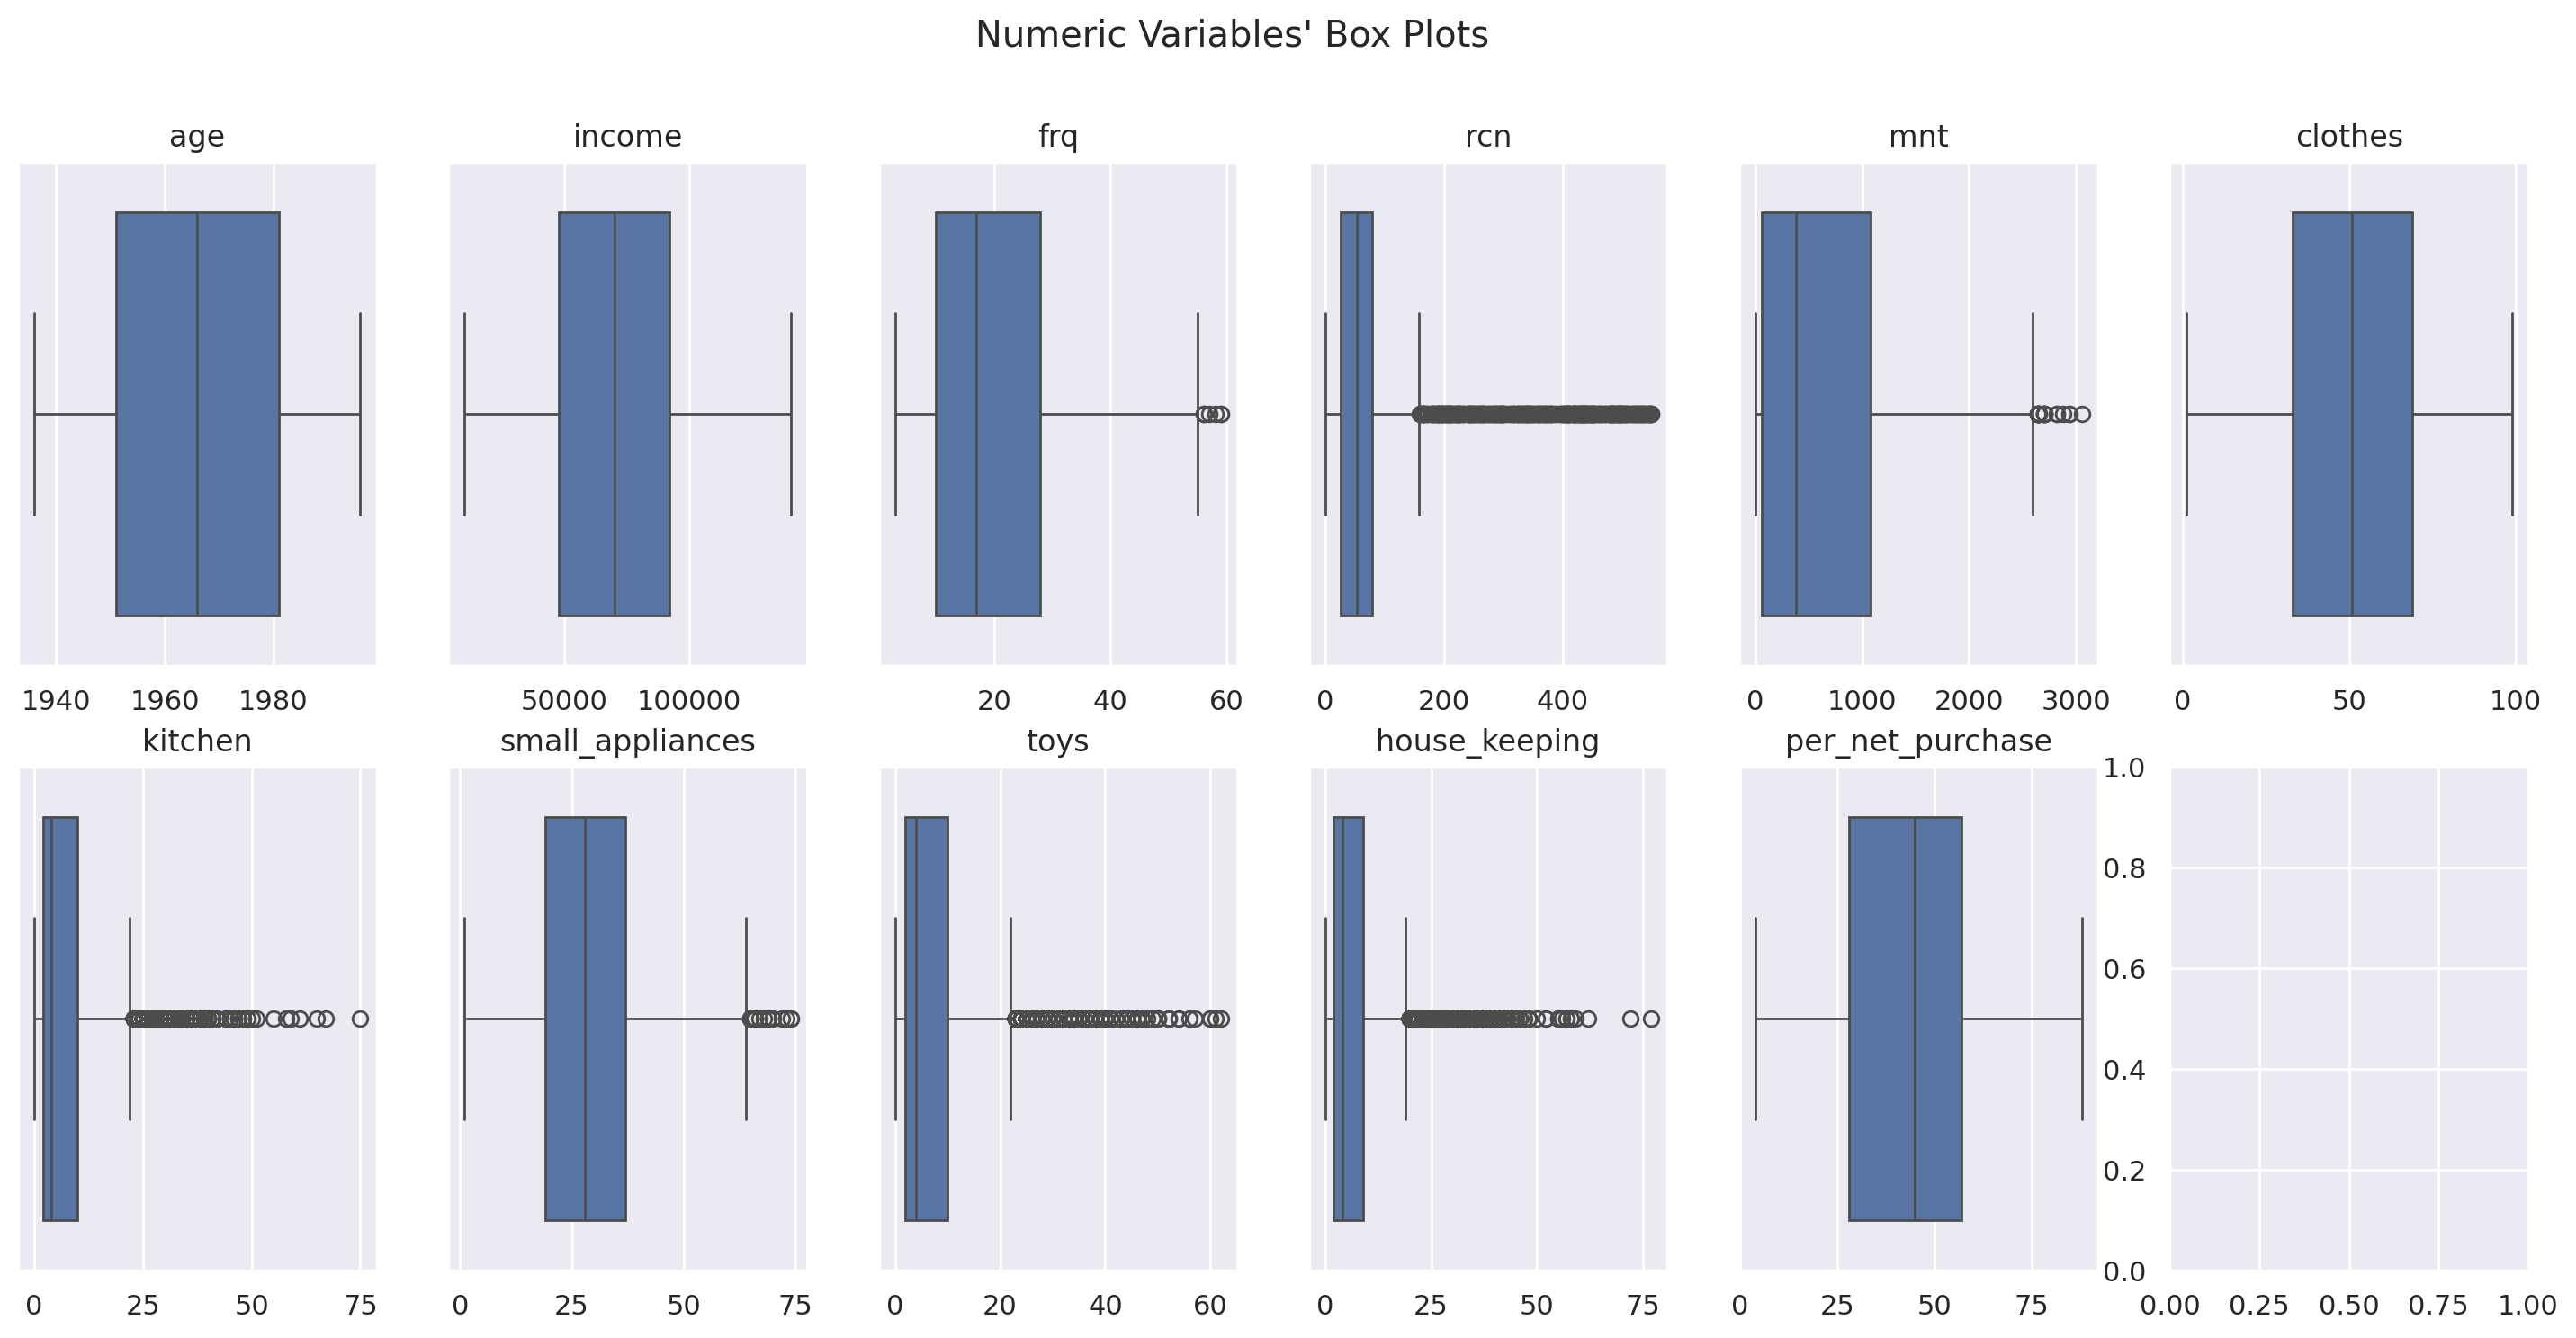

In [27]:
# All Numeric Variables' Histograms in one figure
sns.set()

plot_multiple_boxplots(df, metric_features)


In [28]:
## Try to create the same plots above, but modify the plot title or figsize values

#### Insights:
- univariate distributions
- potential univariate outliers

--------------------------------------

### During our Exploratory Data Analysis (EDA), we must also account for:
- Coherence check
- Outliers
- Missing values
- Feature Engineering

--------------------------------------

### Depending on the context, various steps must be considered when performing Data Preprocessing. The most relevant steps are the following:
- Coherence check (find inconsistent values, missing values, outliers and any other problem you may find in your dataset)
- Data editing (fix inconsistent values)
- Data cleansing (drop observations - Outlier removal and removal of inconsistent values and/or features)
- Data wrangling (feature extraction/engineering and transformation)
- Data reduction (reducing the dimensionality of a dataset, producing summary statistics, reducing the number of records in a dataset)

### Pairwise Relationship of Numeric Variables

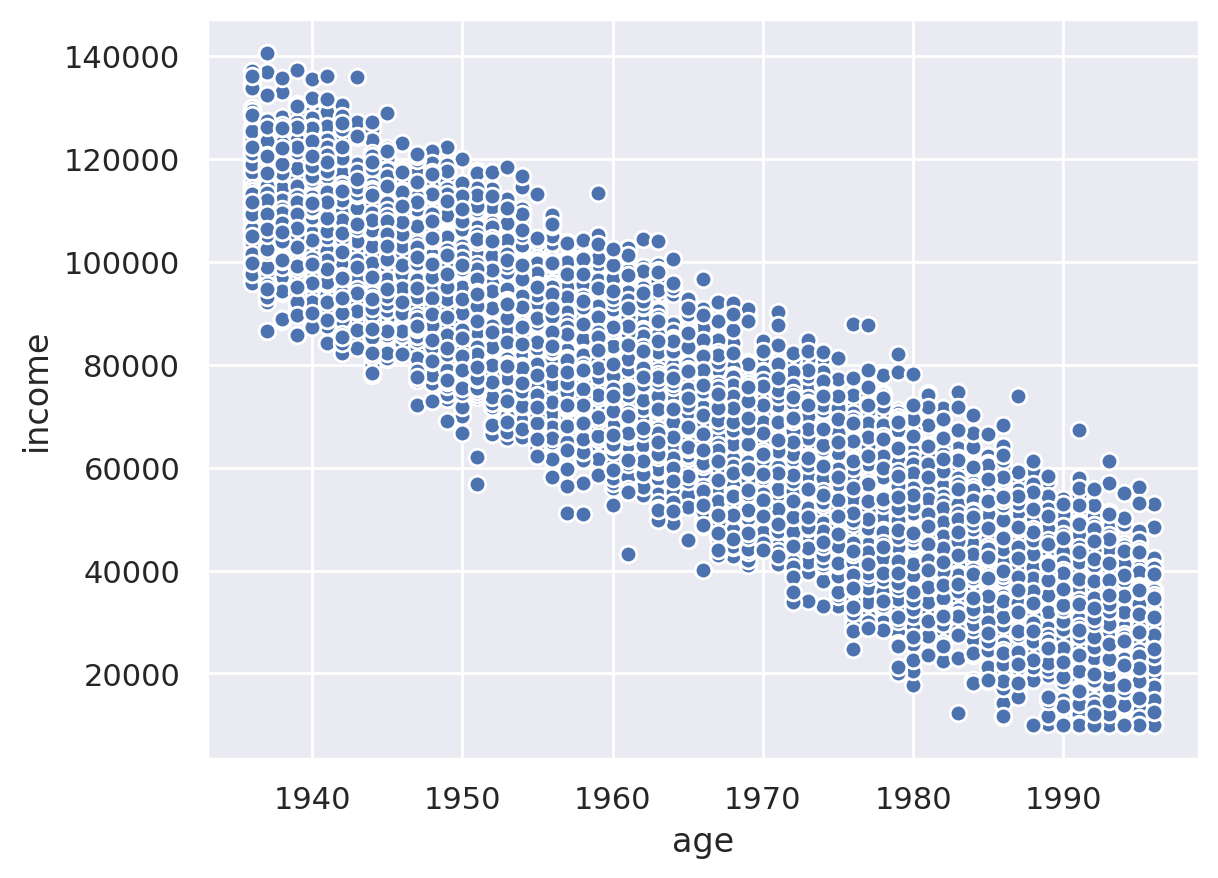

In [29]:
# Pair Metric Variable Scatter plot
plt.scatter(df["age"], df["income"], edgecolors="white")
plt.xlabel("age")
plt.ylabel("income")

plt.show()

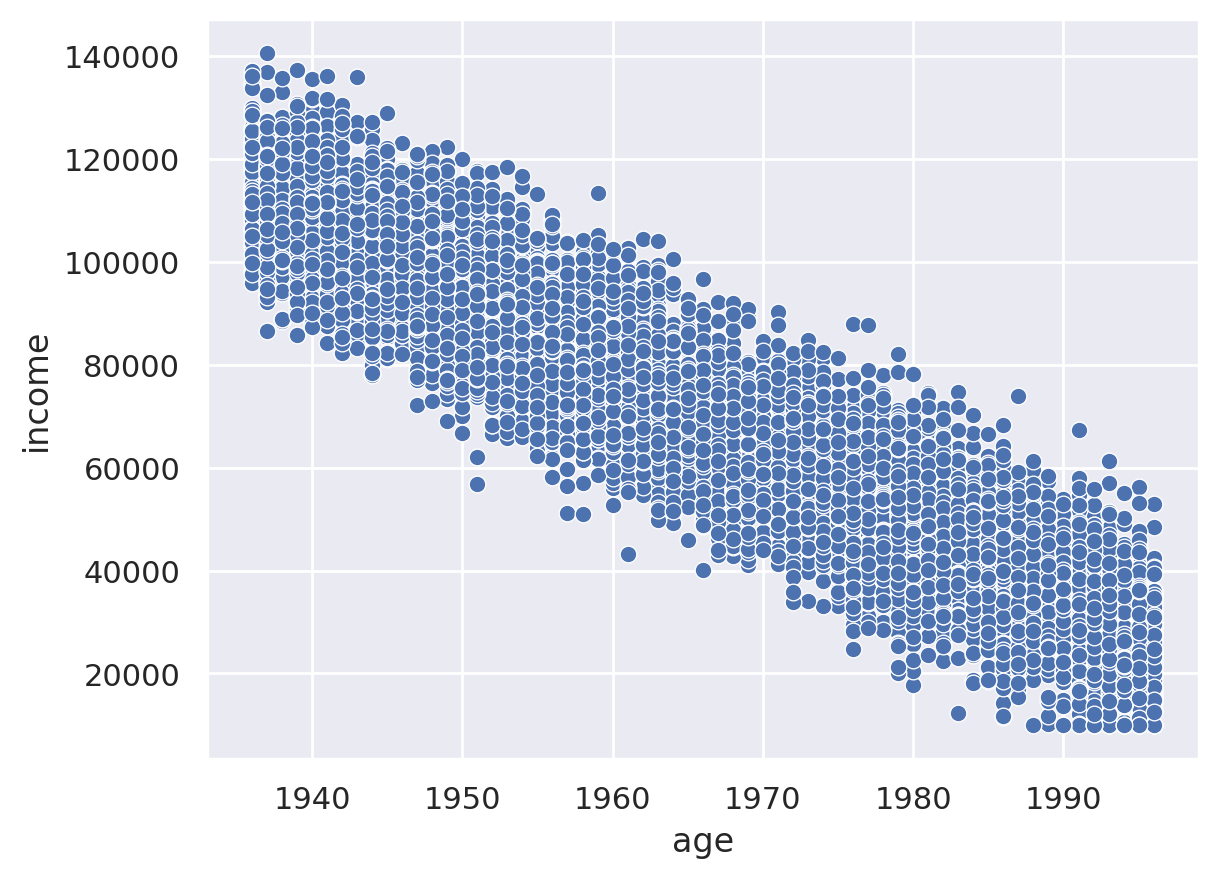

In [30]:
# You can also use seaborn
# Pair Metric Variable Scatter plot

sns.scatterplot(data=df, x="age", y="income")

plt.xlabel("age")
plt.ylabel("income")

plt.show()

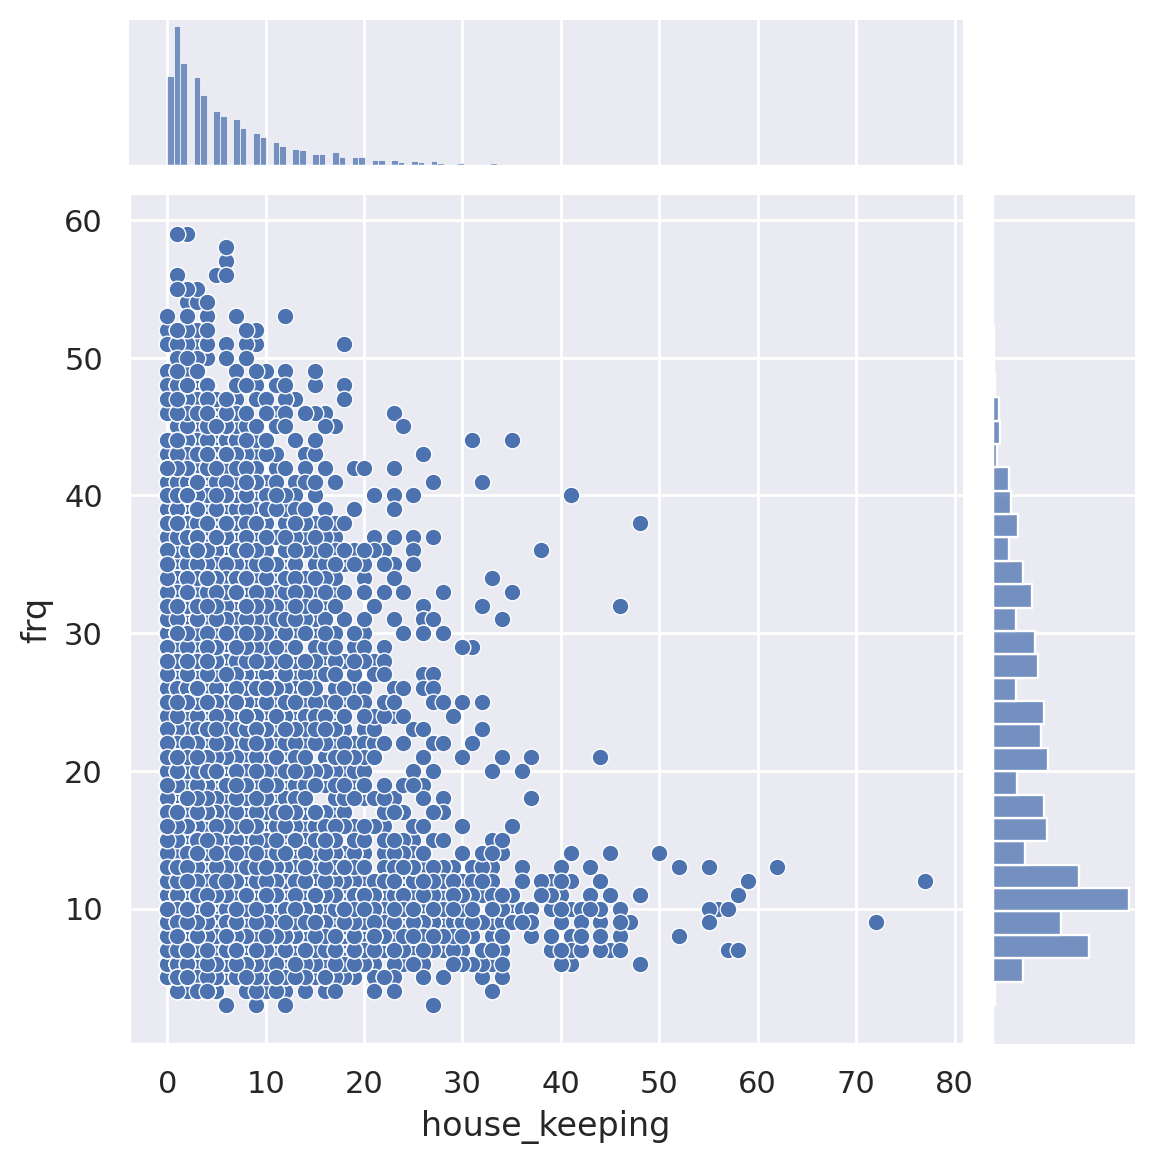

In [31]:
# making a joint plot with default formatting
sns.jointplot(data=df, x="house_keeping", y="frq")
plt.show()


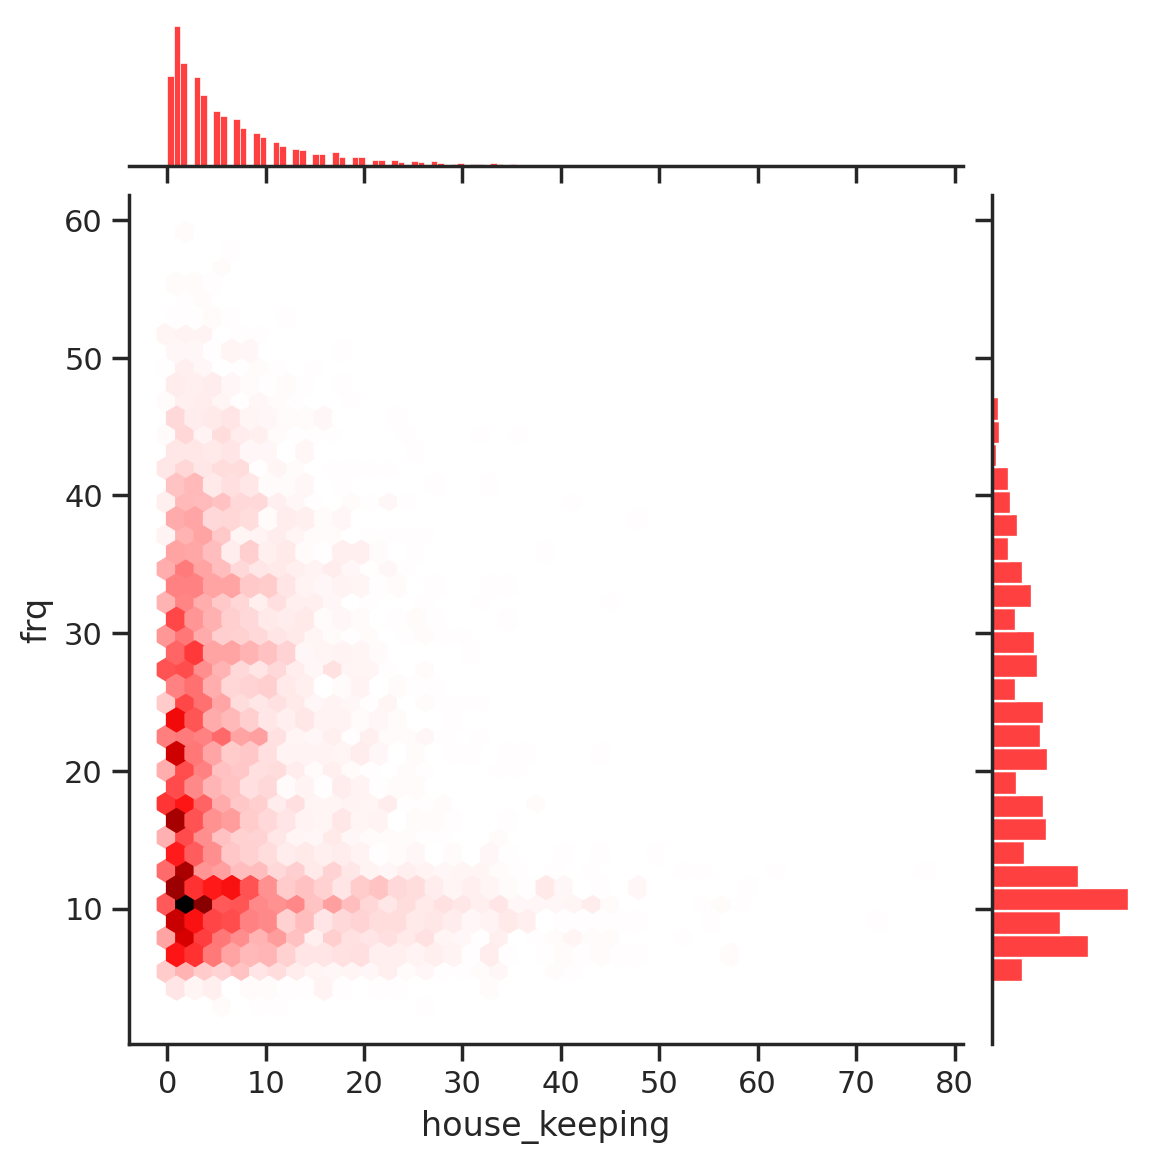

In [32]:
# Making the same visualization with customized formatting
sns.set(style="ticks")
sns.jointplot(data=df, x="house_keeping", y="frq", kind="hex", color="red")
plt.show()

In [33]:
# Pairwise Relationship of All Numerical Variables
sns.set()

# Setting pairplot
sns.pairplot(df[metric_features], diag_kind="hist")

# Layout
plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

#### Insights:
- possible bivariate relationships
- potential bivariate outliers


### Categorical Features Frequencies

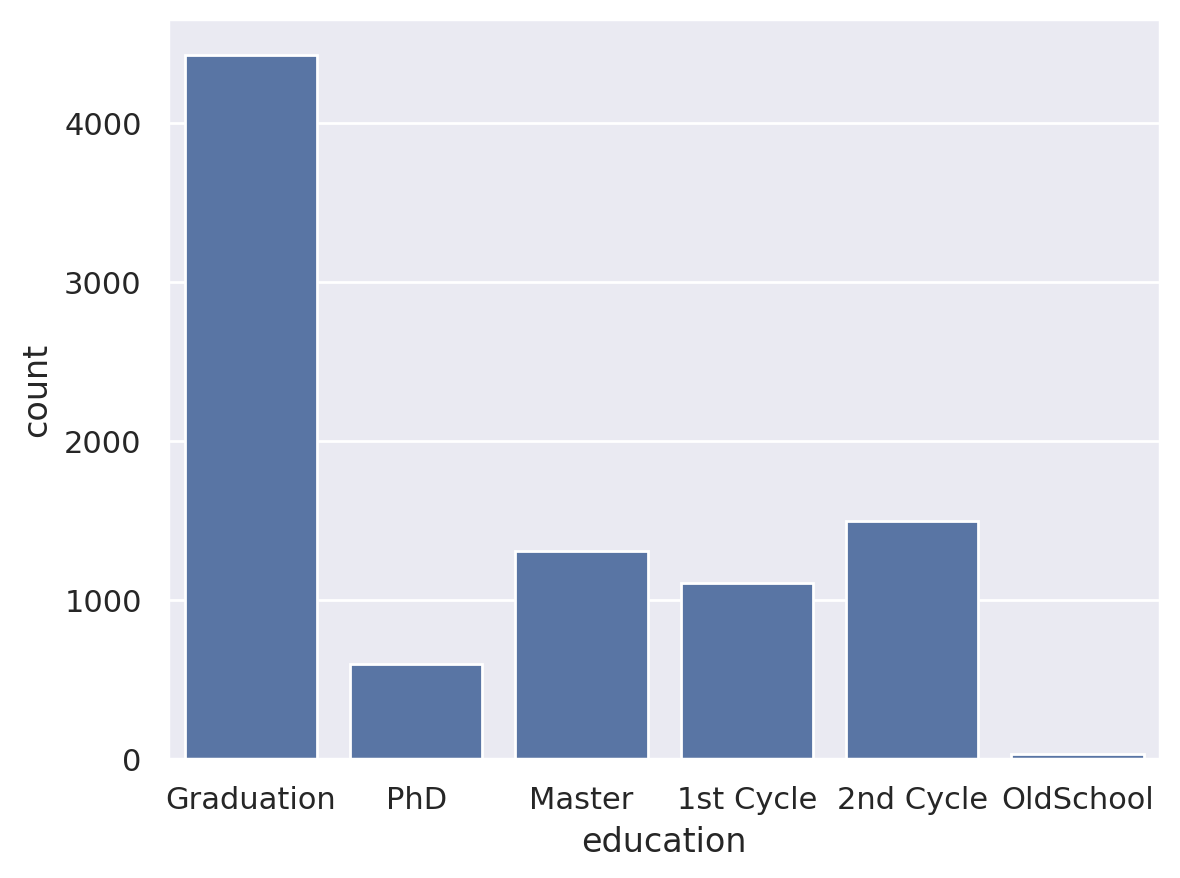

In [34]:
# Single Non-Metric variable bar plot
sns.set()
sns.countplot(x=df["education"])

plt.show()

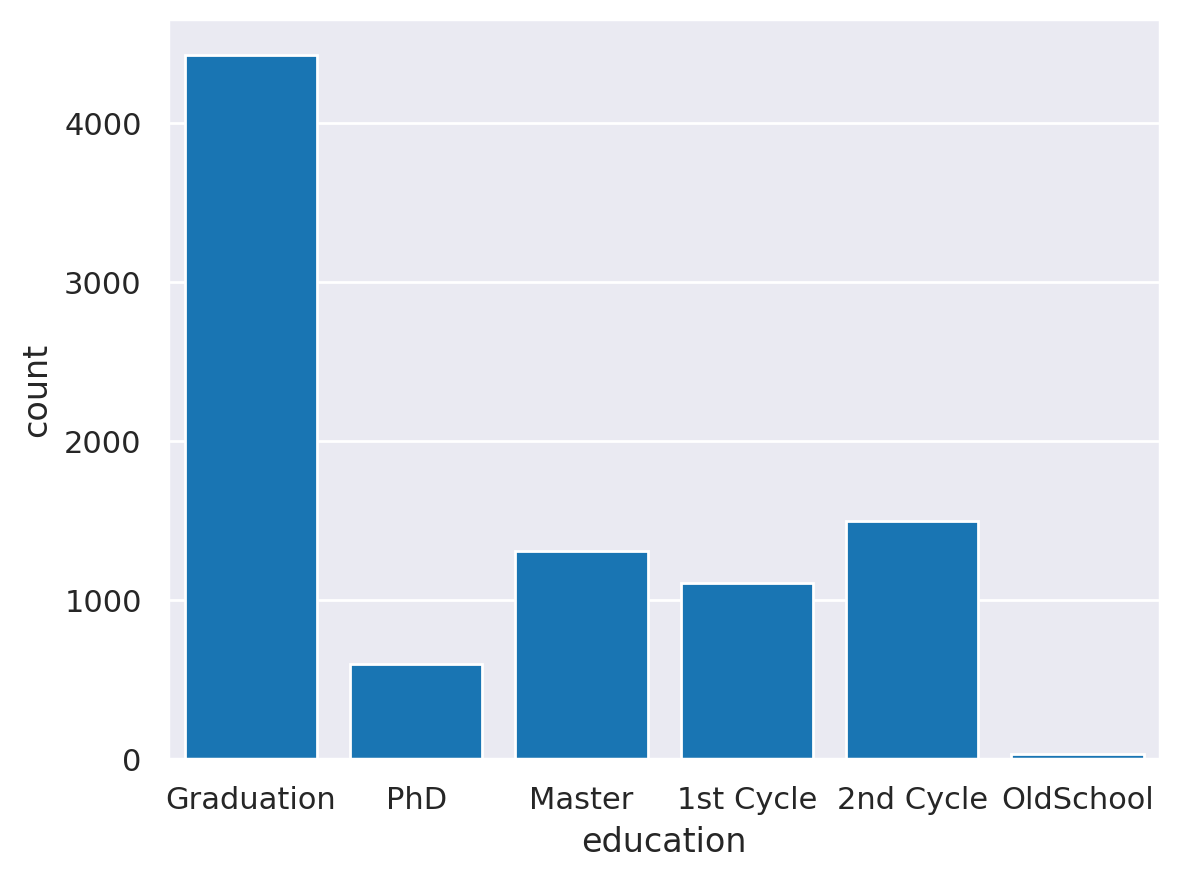

In [35]:
# Same plot, custom color used
sns.countplot(x=df["education"], color='#007acc')
plt.show()


In [50]:
def plot_categorical_frequencies(data, feats,
                                 save_image=False,
                                 image_path="categorical_variables_histograms.png",
                                 title="Categorical Variables' Frequencies",
                                 horizontal=True):
    n = len(feats)
    ncols = ceil(np.sqrt(n))
    nrows = ceil(n / ncols)

    # less height per row to avoid vertical stretch
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 2.6*nrows), constrained_layout=True)
    axes = axes.flatten()

    for ax, feat in zip(axes, feats):
        ser = data[feat].astype("object").fillna("Missing")
        if horizontal:
            sns.countplot(y=ser, ax=ax, color="#007acc")
            ax.tick_params(axis="y", labelsize=9)
        else:
            sns.countplot(x=ser, ax=ax, color="#007acc")
            ax.tick_params(axis="x", rotation=90, labelsize=9)
        ax.set_title(str(feat), fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("")

        # trim extra whitespace
        ax.margins(x=0.02, y=0.05)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=0.93)

    if save_image:
        fig.savefig(image_path, dpi=150, bbox_inches="tight")

    plt.show()

/tmp/ipython-input-889840855.py:33: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.93)


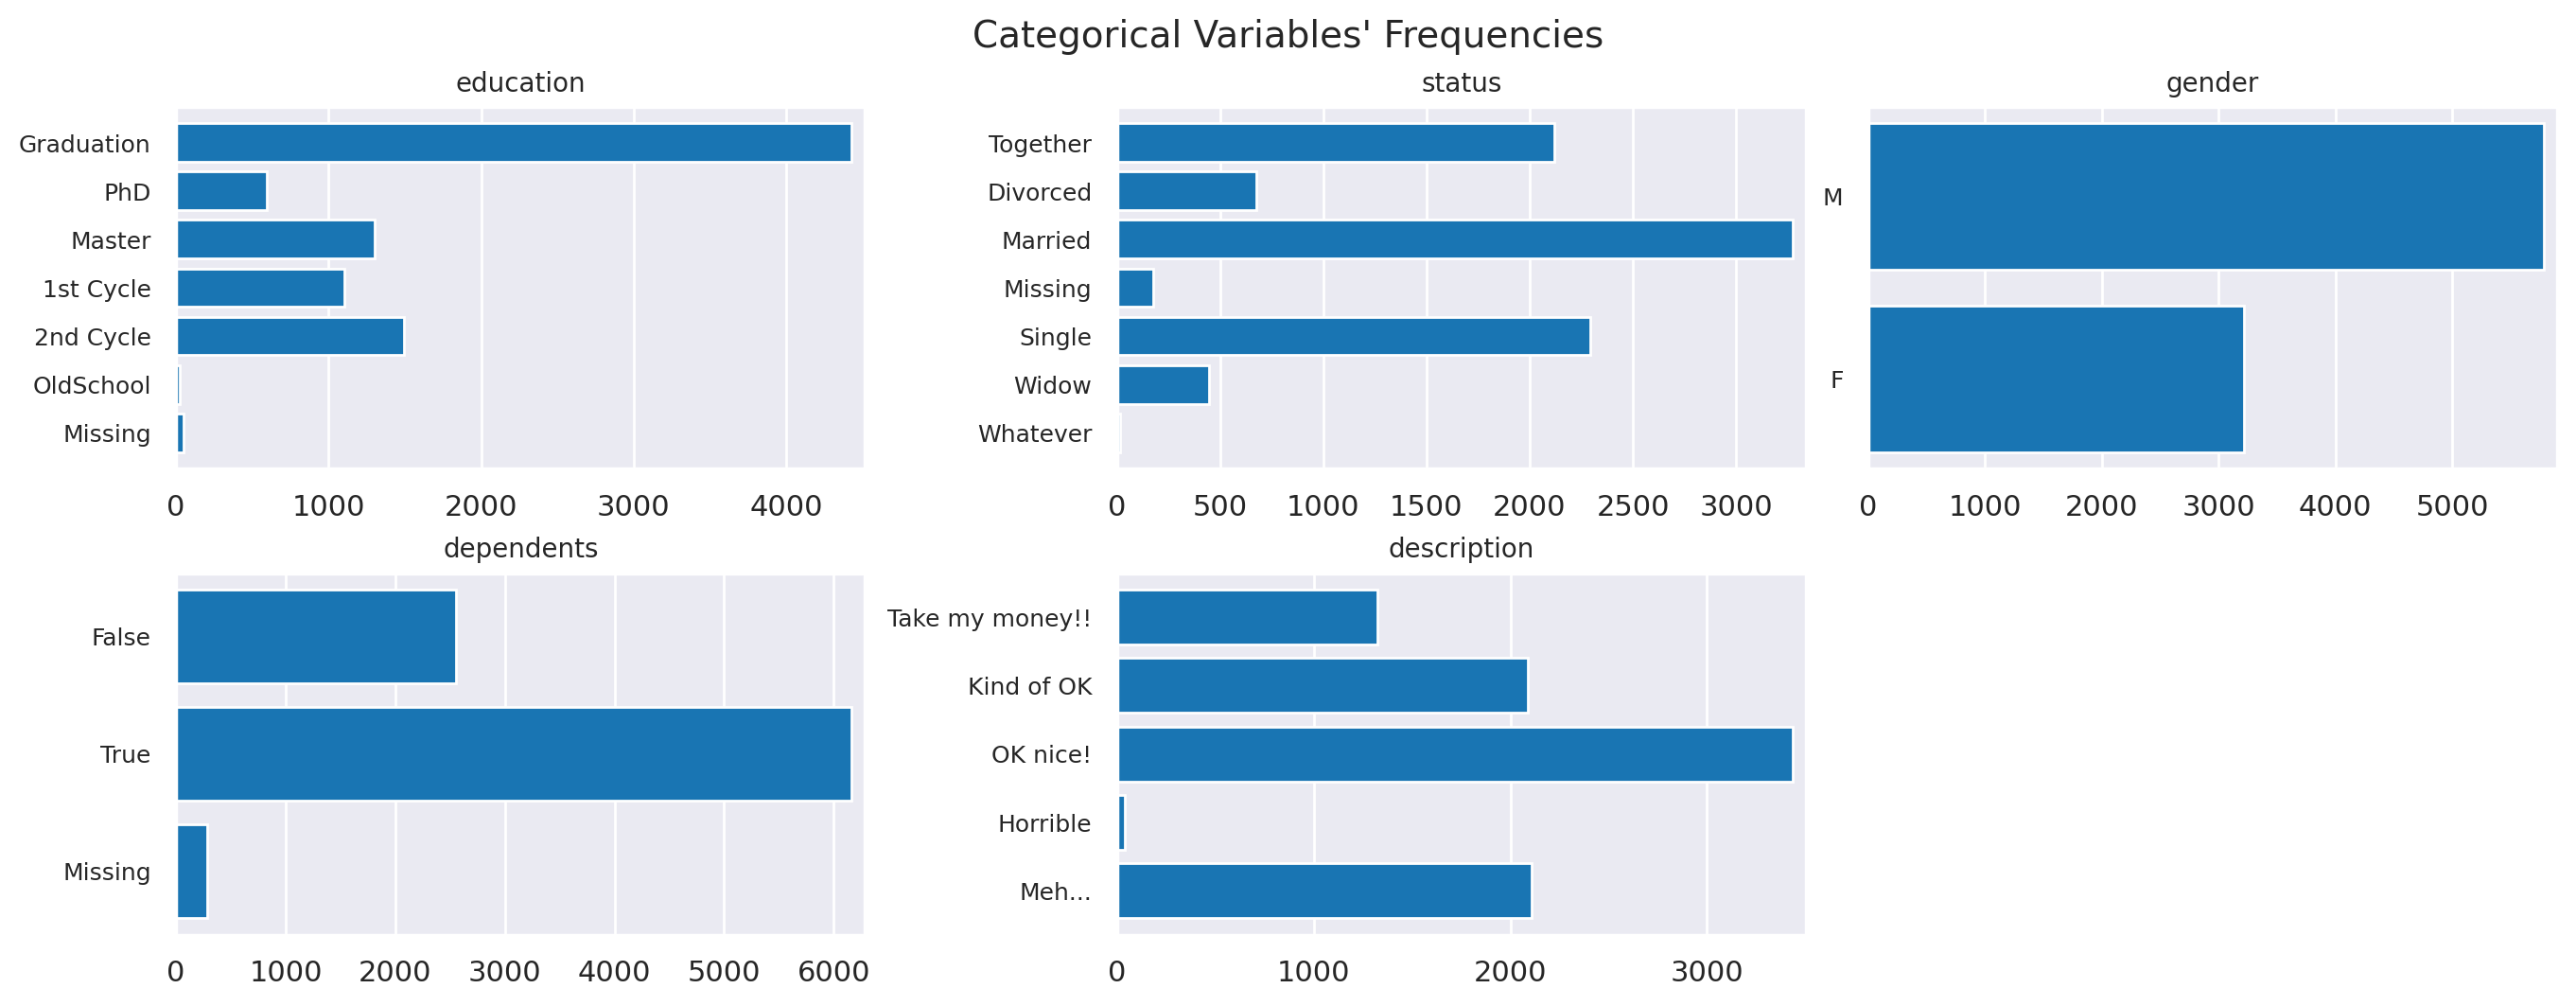

In [51]:
plot_categorical_frequencies(df, non_metric_features)

/tmp/ipython-input-889840855.py:33: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.93)


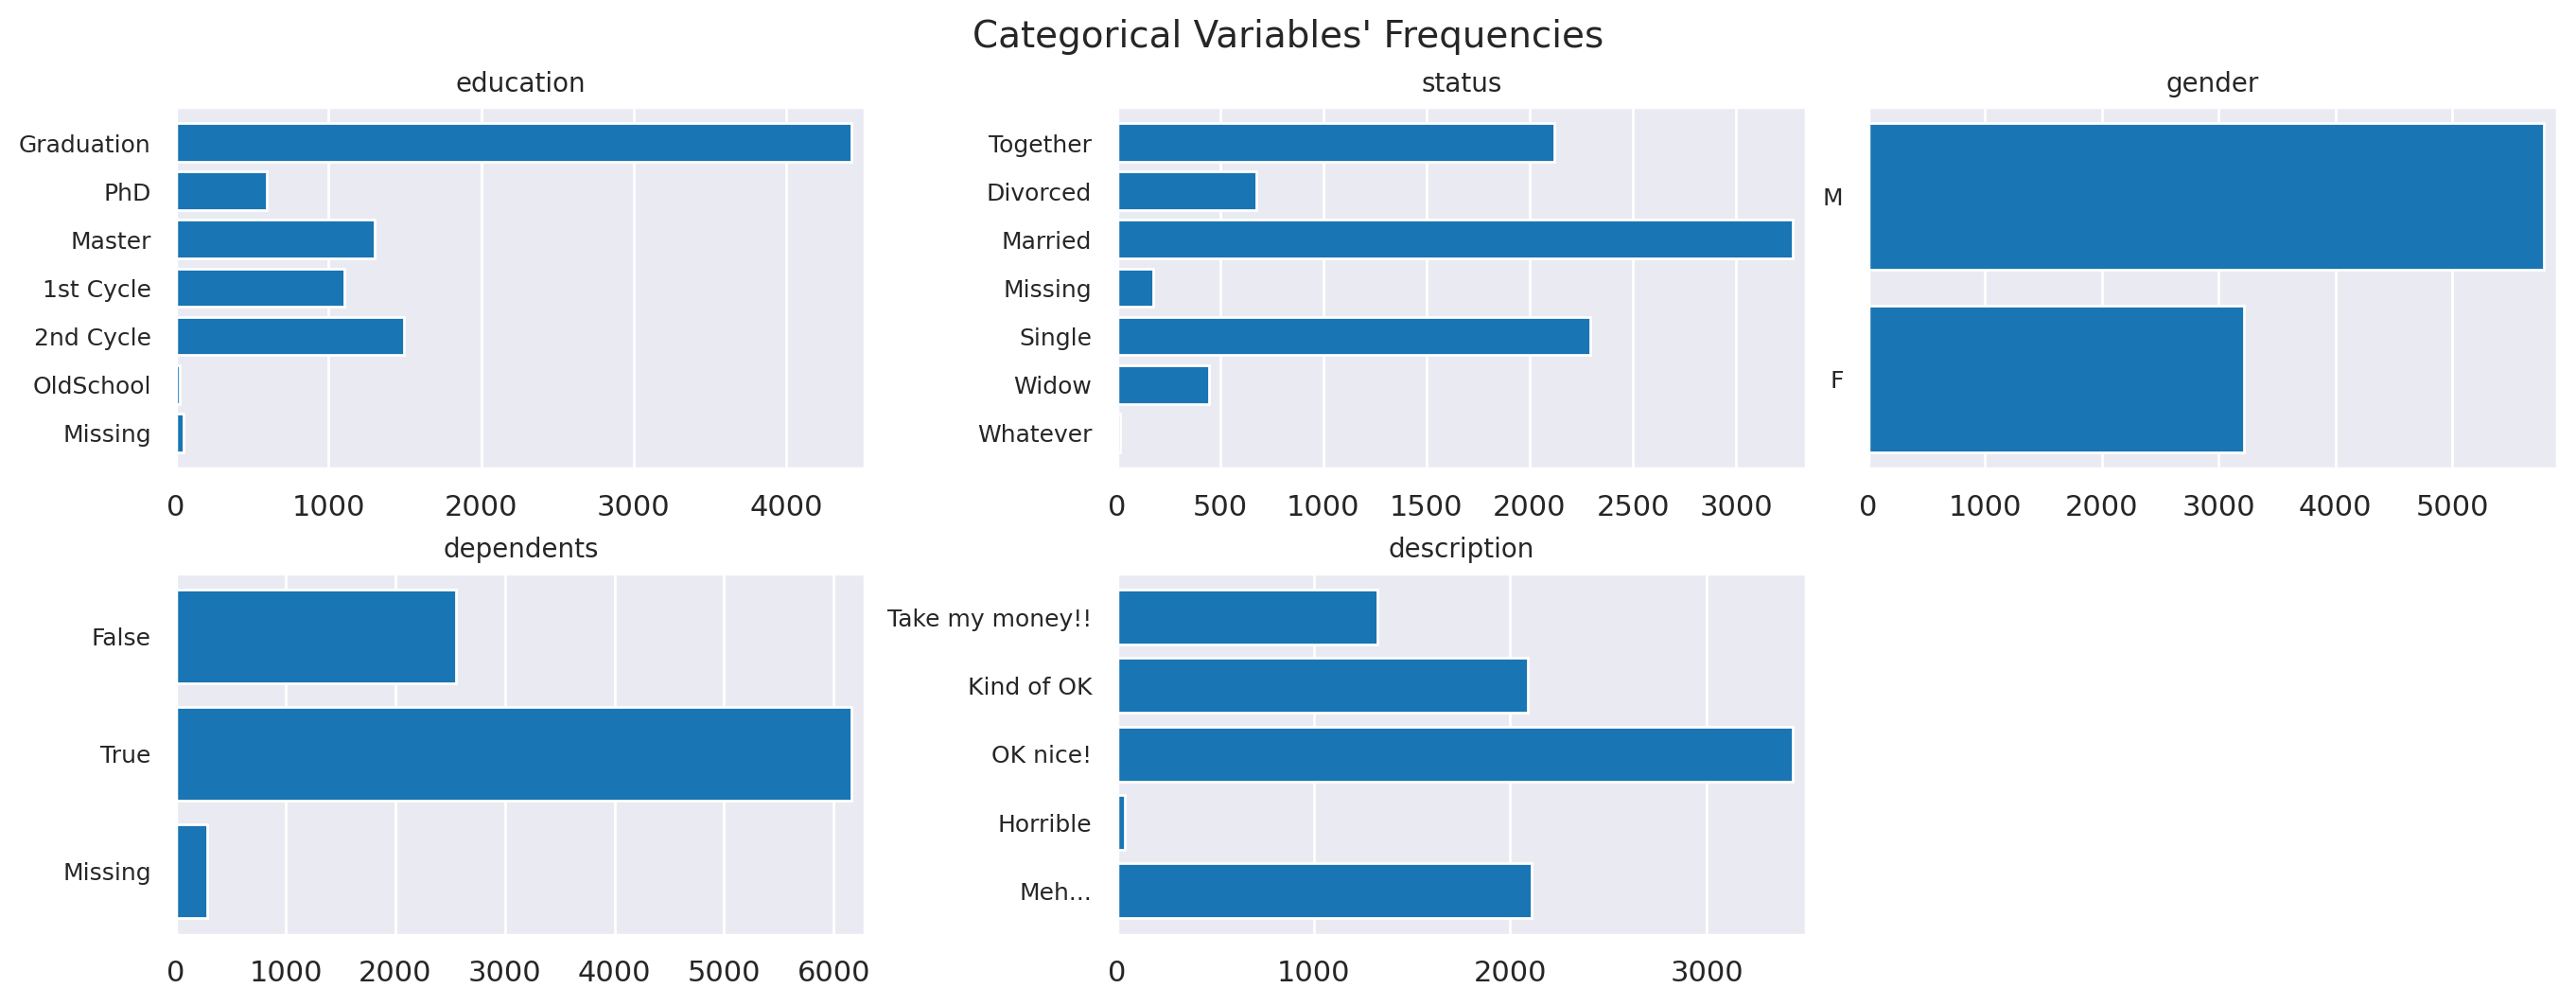

In [52]:
## Run the code again, but save the image.
## Where did the image go?

plot_categorical_frequencies(df, non_metric_features, save_image=True)


### Comparing Two Categorical Features

In [53]:
## Define a function that creates a plot comparing two categorical features

def plot_cat_cat(df, cat1, cat2, title=None):
  df.groupby([cat1, cat2]).size().unstack().plot.bar(stacked=True)
  if title==None:
    plt.title("Plot of {} and {}".format(cat1, cat2))
  else:
    plt.title(title)

  plt.show()
  return



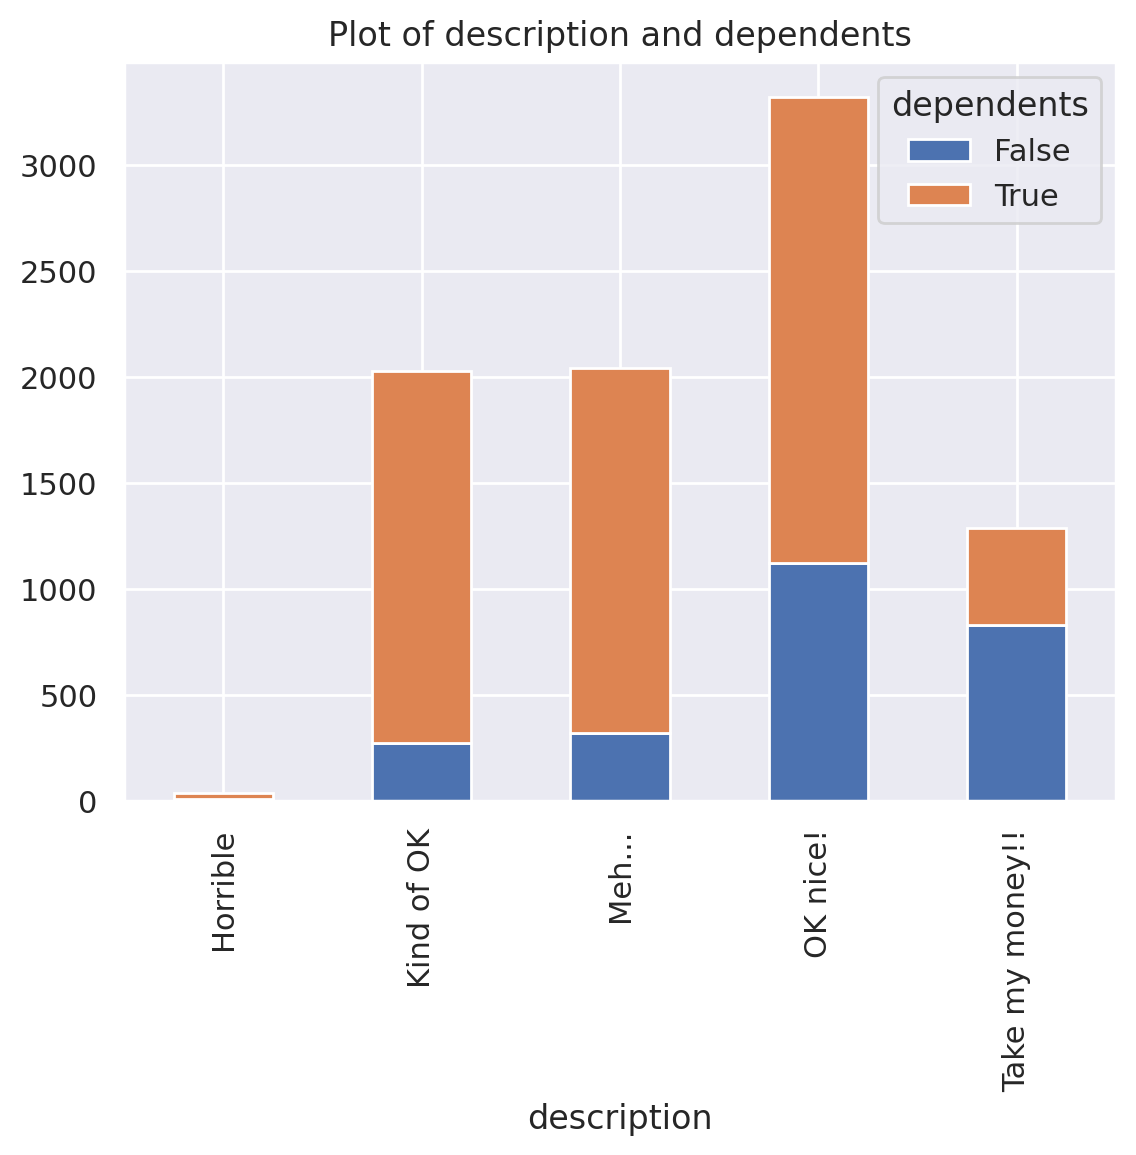

In [57]:
sns.set()

plot_cat_cat(df, 'description', 'dependents')

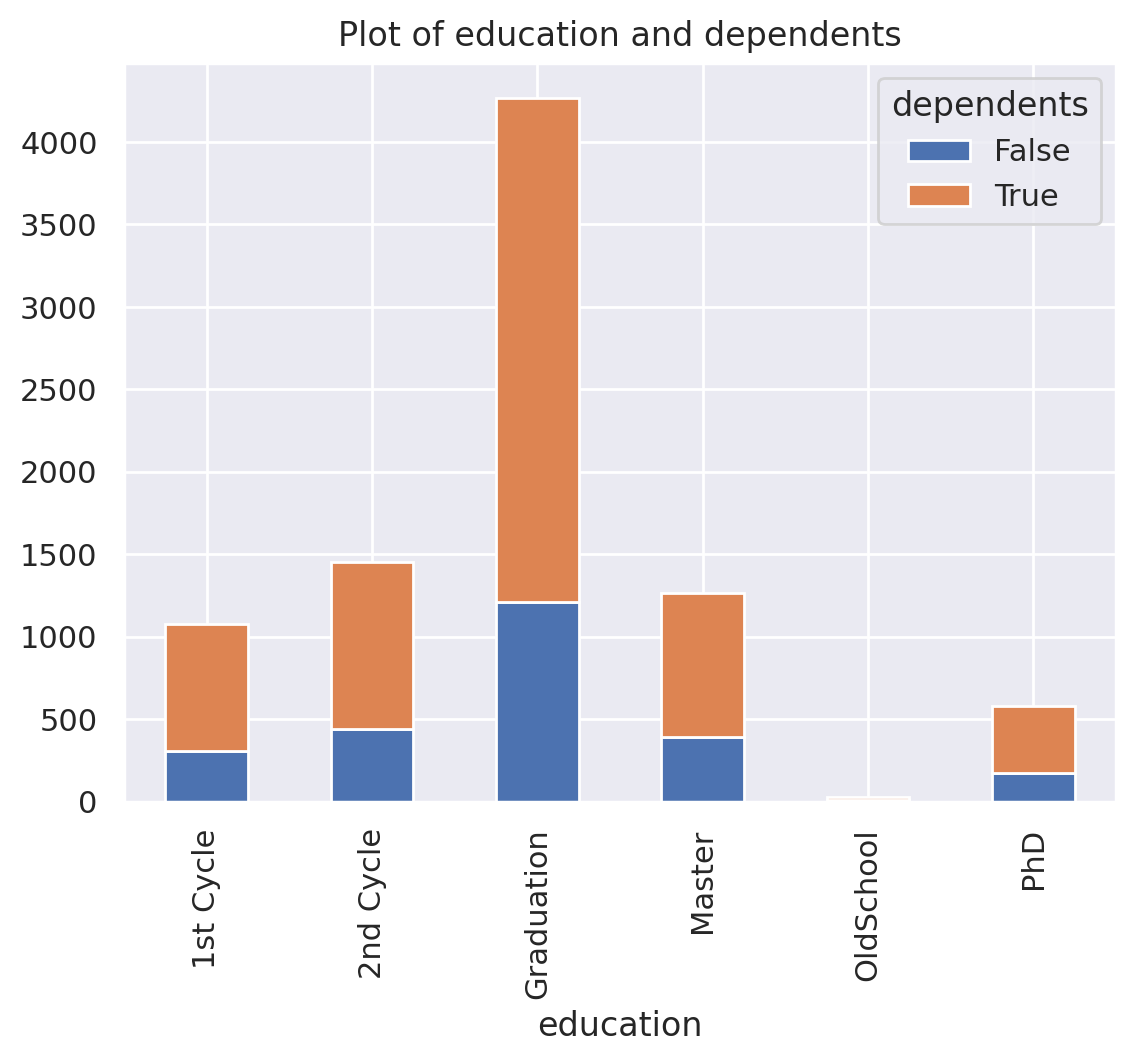

In [58]:
## Try a different pair
plot_cat_cat(df, 'education', 'dependents')

### Comparing Categorical vs Continuous Variables

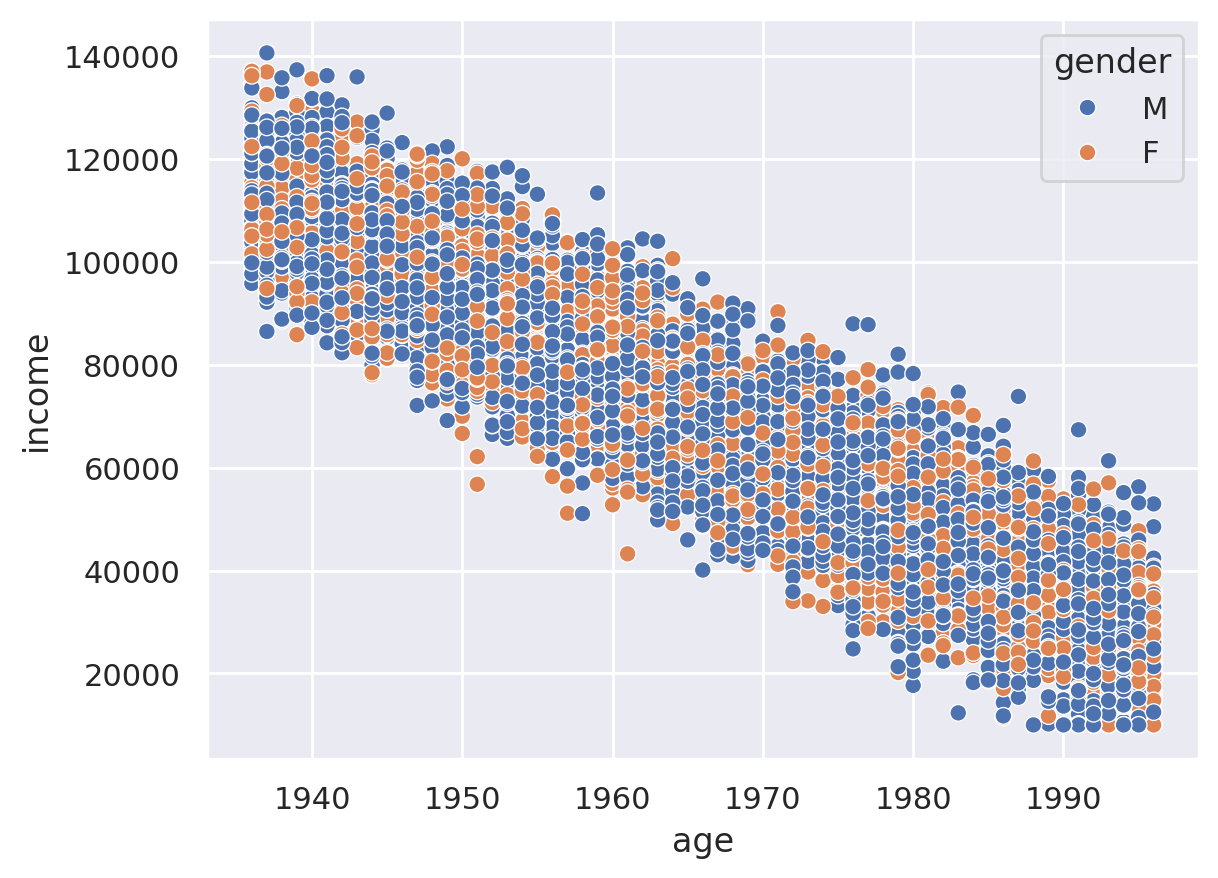

In [59]:
# Pair Metric Variable Scatter plot with categorical feature

sns.scatterplot(data=df, x="age", y="income", hue="gender")

plt.xlabel("age")
plt.ylabel("income")

plt.show()

In [ ]:
## This cell takes a long time to run.

# Pairwise Relationship of Numerical Variables
sns.set()

# Setting pairplot
sns.pairplot(df[metric_features + ['gender']], diag_kind="hist", hue='gender')

# Layout
plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)

plt.show()

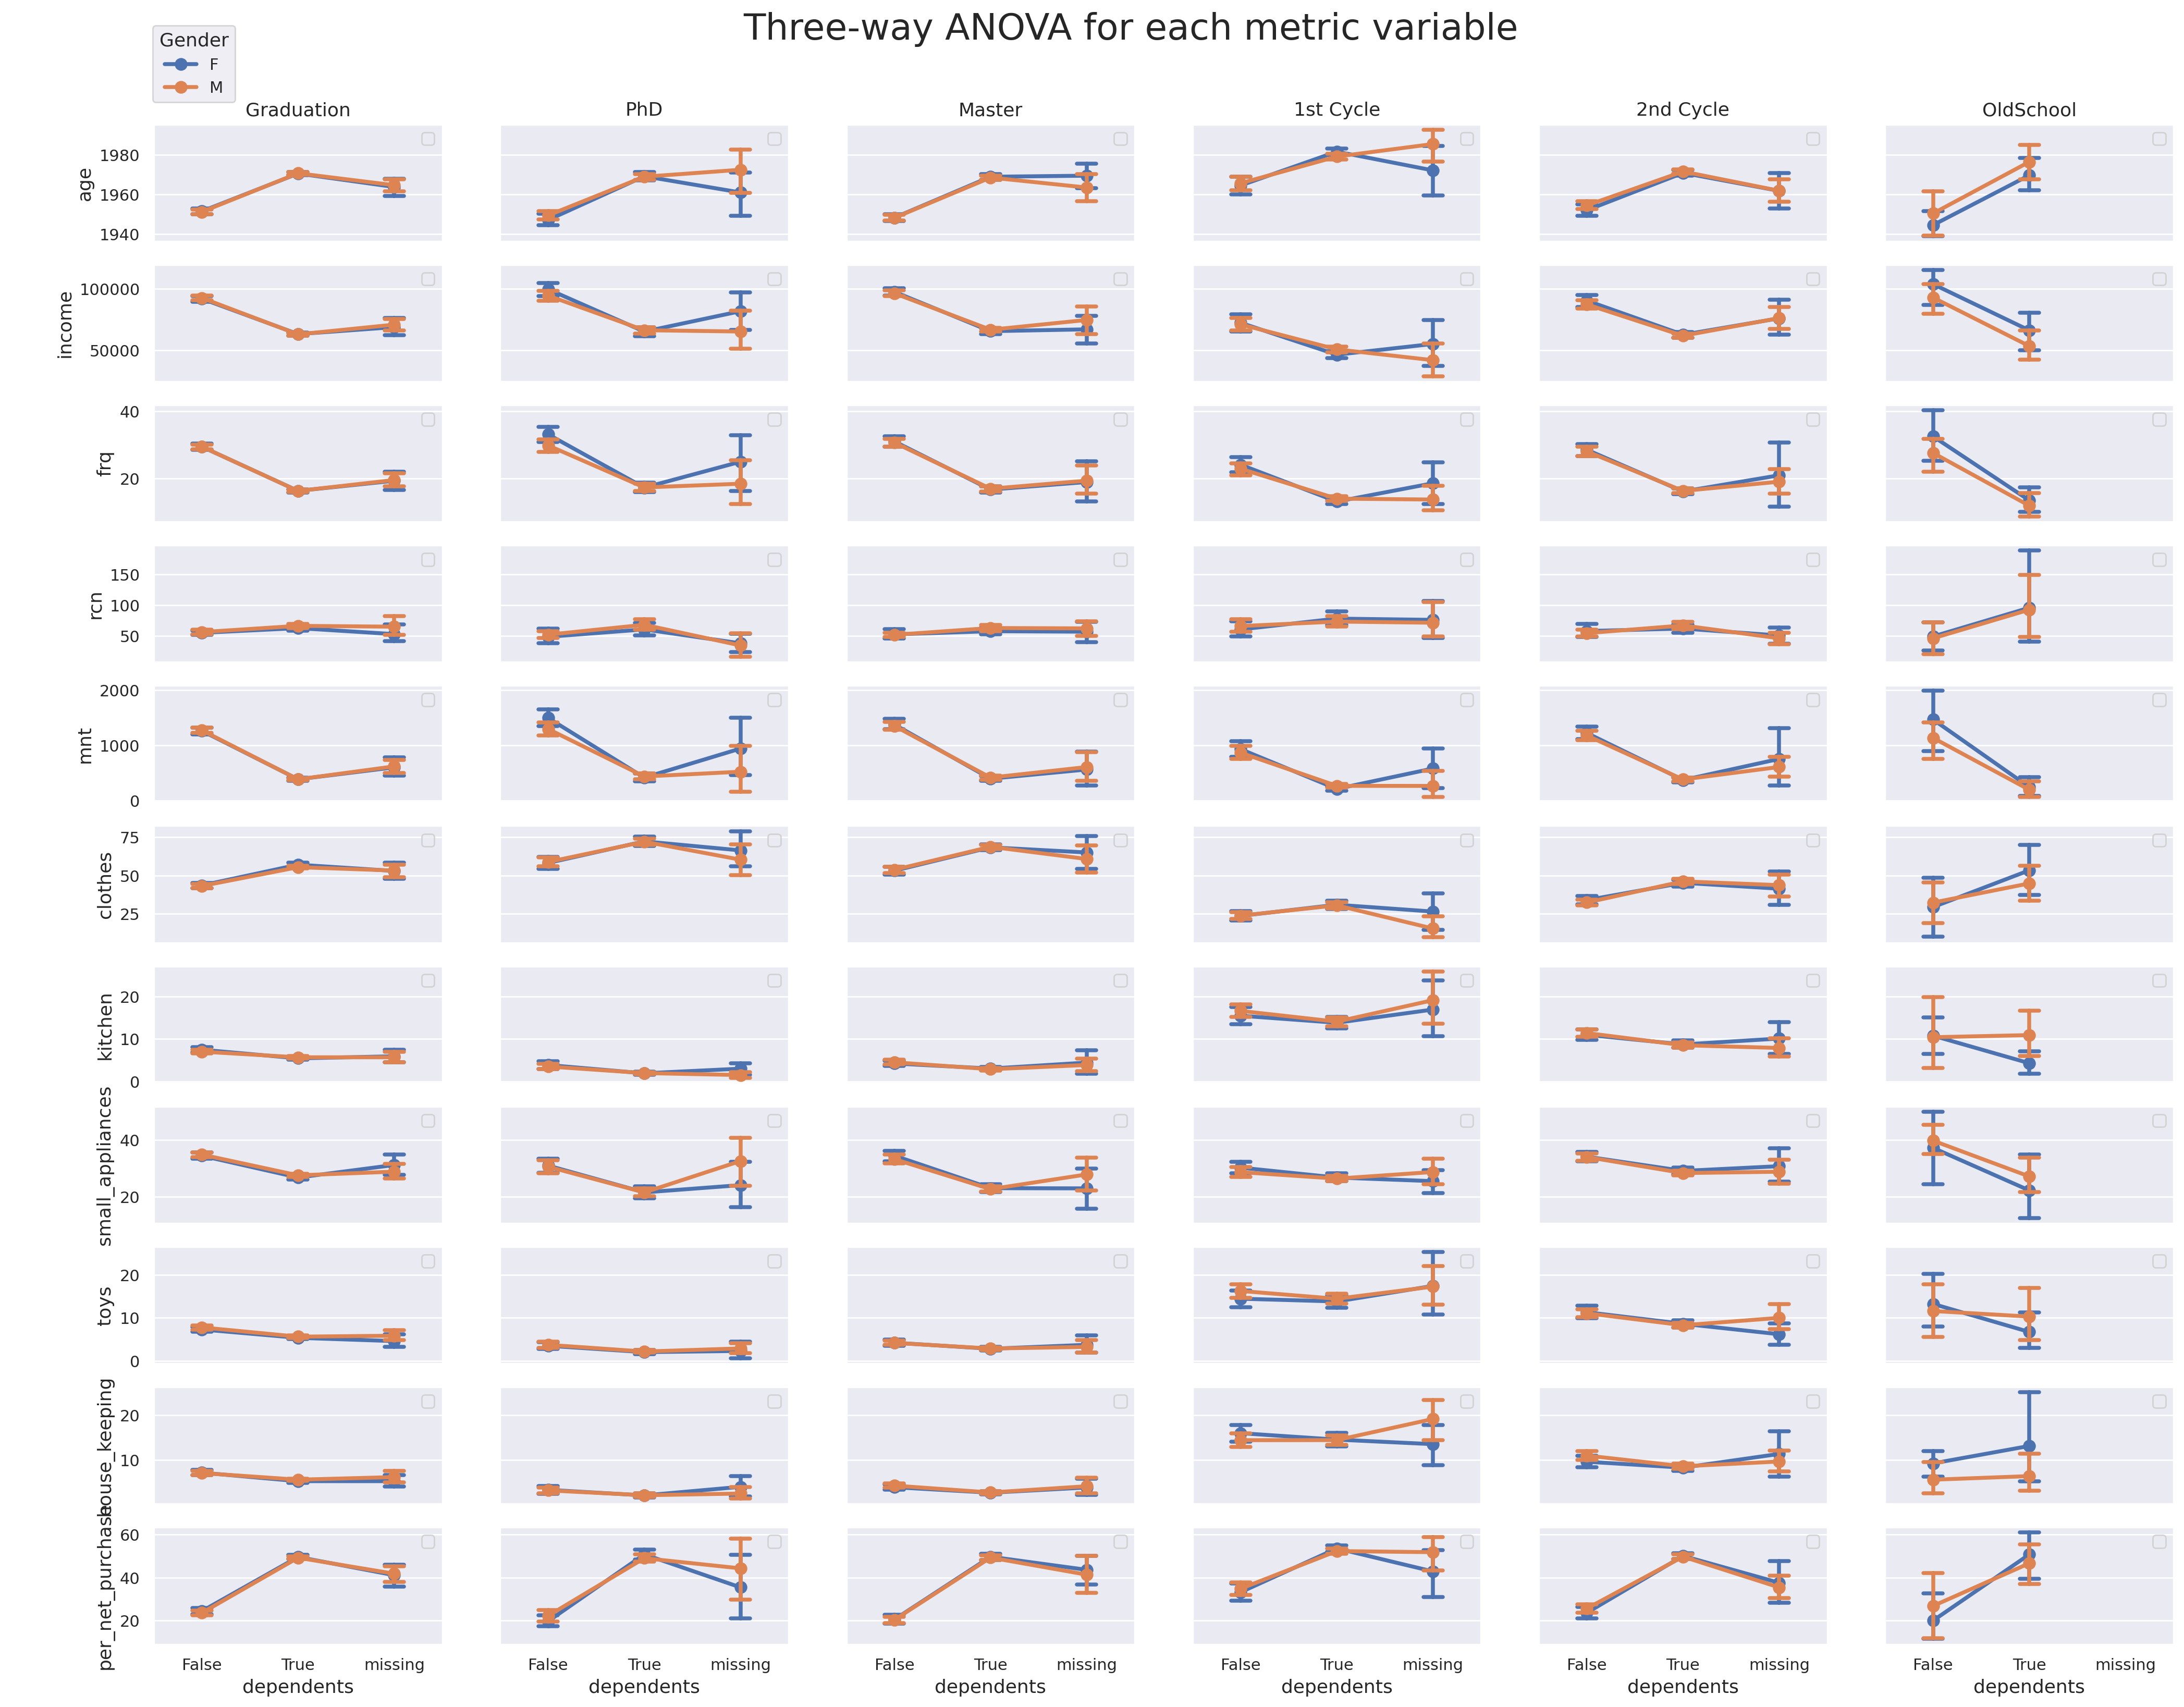

In [66]:
# notice we drop missing values in order to not plot it as a distinct value
educ_vals = df.education.dropna().unique()
educ_vals = educ_vals

fig, axes = plt.subplots(len(metric_features), len(educ_vals), figsize=(25,18), sharex=True, sharey="row")


for ax, (feat, educ_deg) in zip(axes.flatten(), product(metric_features, educ_vals)):
    # get the data for each subplot
    data = df.loc[df.education == educ_deg,:].copy()
    data['dependents'] = data['dependents'].astype(object).fillna("missing")

    # we are distinguishing points according to the variable "dependents"
    sns.pointplot(x="dependents", y=feat, hue="gender", hue_order=["F", "M"], data=data, capsize=.2, ax=ax)

    # remove the typical default y and x labels and legend of each axis
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend('')

# set columns' titles (education)
for ax, label in zip(axes[0,:], educ_vals):
    ax.set_title(label, fontsize=13)

# set metric names
for ax, label in zip(axes[:,0], metric_features):
    ax.set_ylabel(label, fontsize=13)

# set x axis label (dependents)
for ax in axes[-1,:]:
    ax.set_xlabel('dependents', fontsize=13)

# Set legend (gender)
handles, _ = axes[0,0].get_legend_handles_labels()
fig.legend(handles, ["F","M"], loc=(0.07,0.94), title="Gender", title_fontsize=13)

# set figure
plt.subplots_adjust(top=0.92)
plt.suptitle("Three-way ANOVA for each metric variable", fontsize=25)

plt.show()

### Metric Variables Correlation Matrix

In [67]:
def plot_corr_matrix(df, feats, title="Correlation Matrix", method="pearson", figsize=(10,8)):

  # Prepare figure
  fig = plt.figure(figsize=figsize)

  # Obtain correlation matrix. Round the values to 2 decimal cases. Use the DataFrame corr() and round() method.
  corr = np.round(df[feats].corr(method=method), decimals=2)

  # Build annotation matrix (values above |0.5| will appear annotated in the plot)
  mask_annot = np.absolute(corr.values) >= 0.5
  annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) # Try to understand what this np.where() does

  # Plot heatmap of the correlation matrix
  sns.heatmap(data=corr, annot=annot, cmap=sns.diverging_palette(220, 10, as_cmap=True),
              fmt='s', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

  # Layout
  fig.subplots_adjust(top=0.95)
  fig.suptitle(title, fontsize=20)

  plt.show()


  return



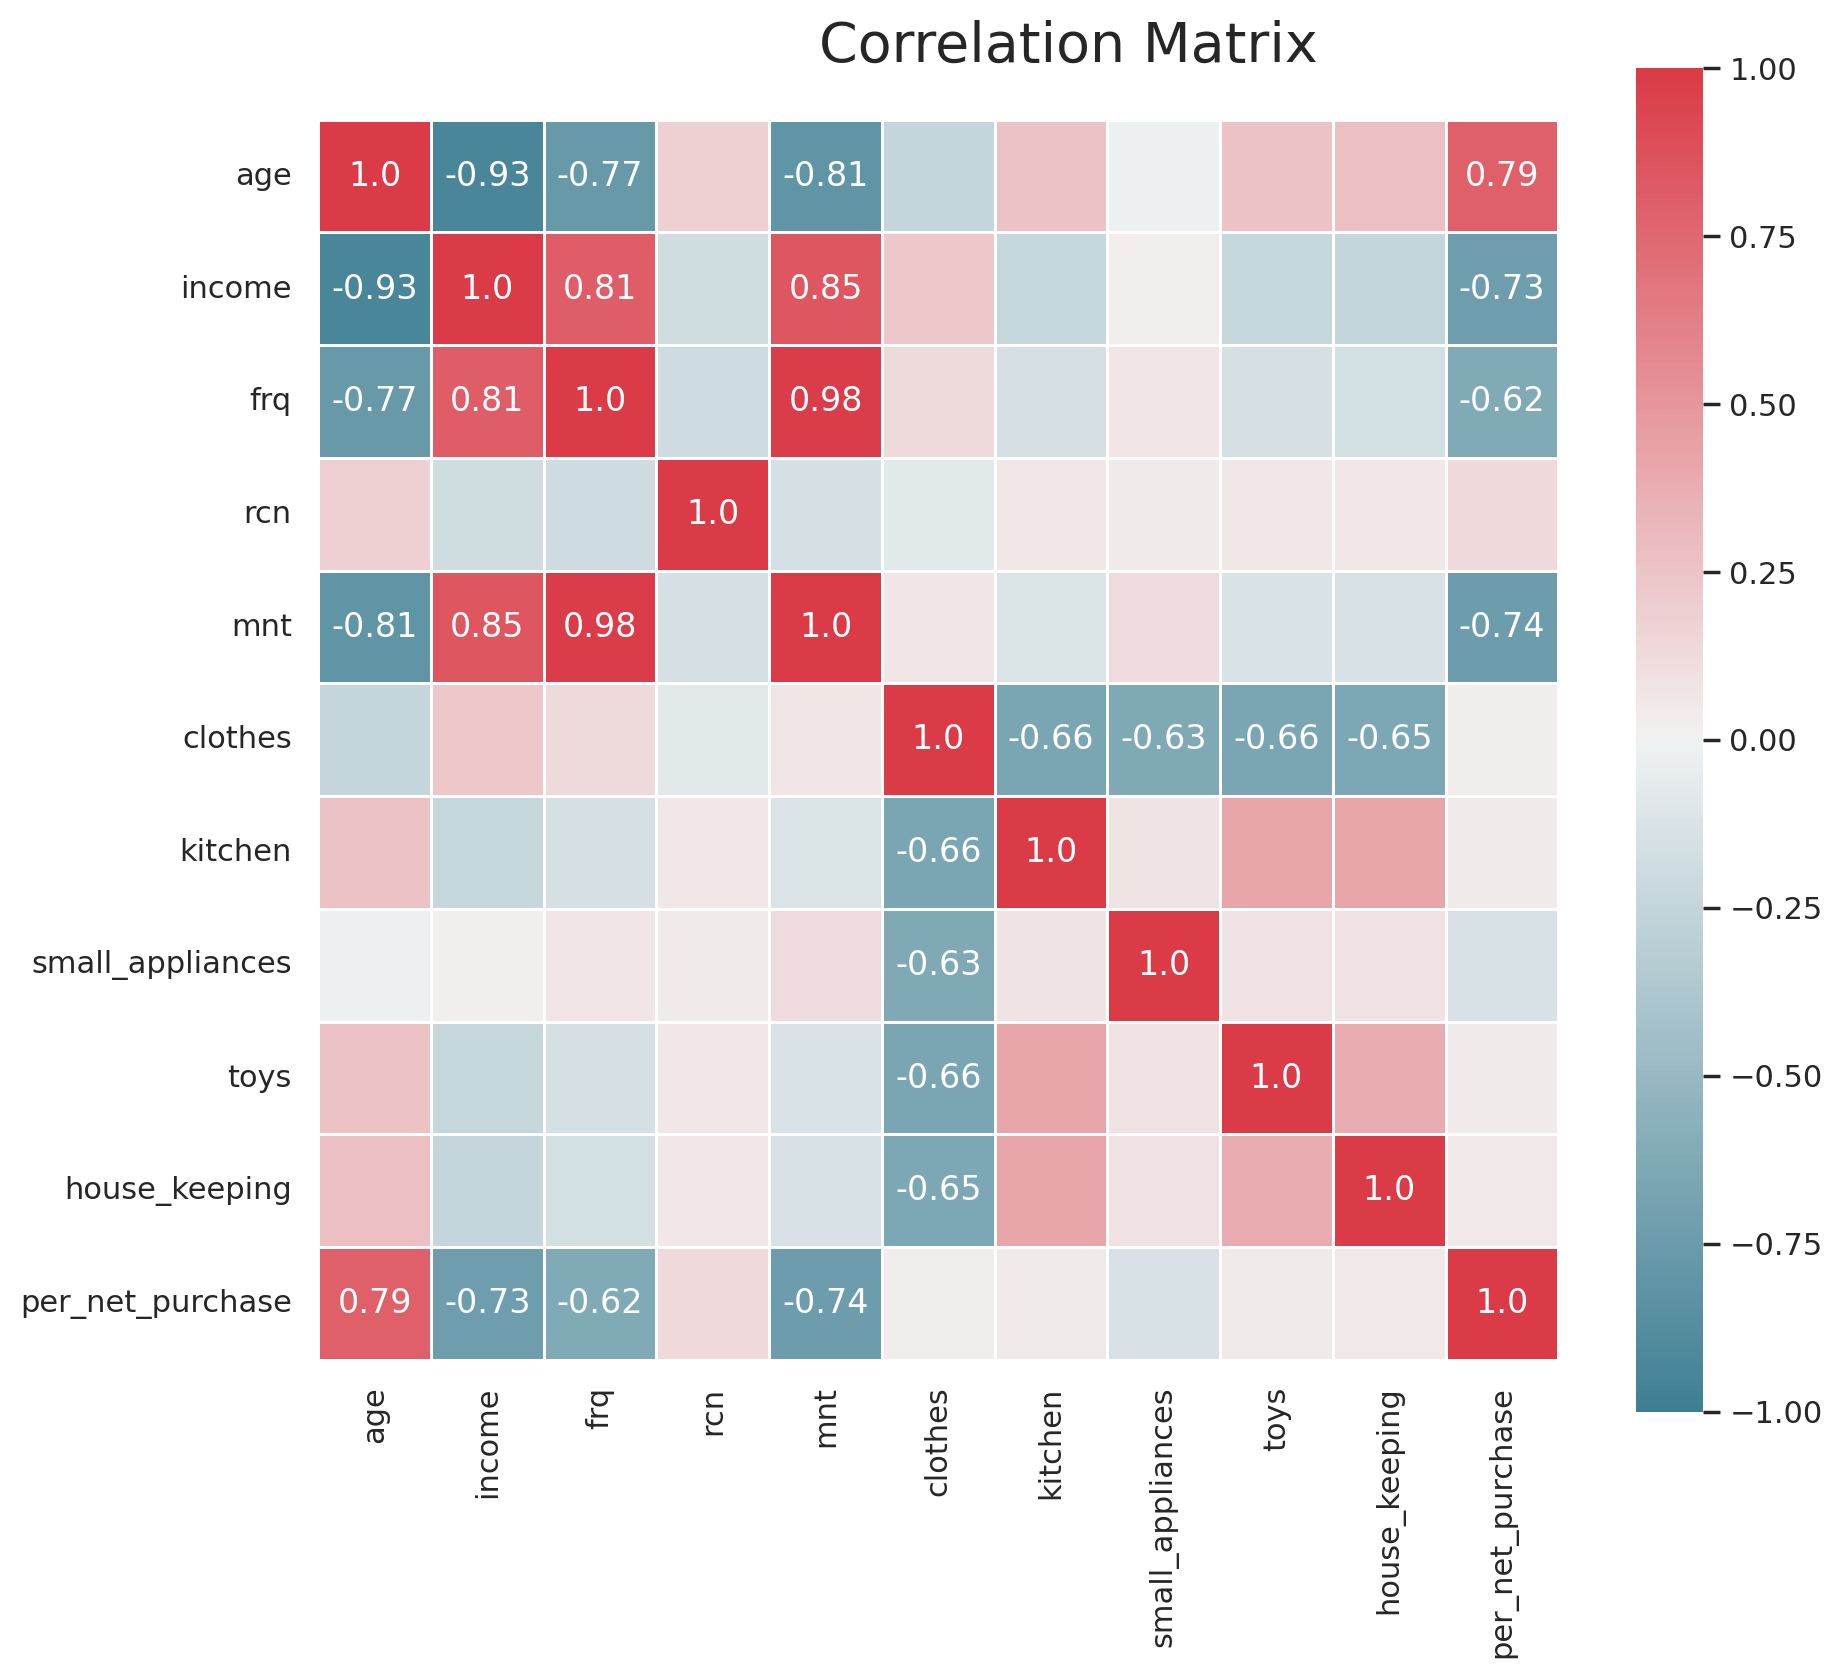

In [68]:
plot_corr_matrix(df, metric_features )

### Using `ydata-profiling`

#### A tool to assist you through your exploratory data analysis

Optionally, you may use `pandas-profiling` as a first approach to your data analysis. Remember, although this tool provides excelent insights about the data you're working with, it is not enough to perform a proper analysis.

In [69]:
profile = ProfileReport(
    df,
    title='Tugas Customer Data',
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
        "cramers": {"calculate": False},
    },
)

In [70]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

### Insights

## Next Session: Data Preprocessing

## Questions?

## [OPTIONAL] Exercise

To practice your exploration and visualization skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [ ]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [ ]:
## Load the first 5 rows of the data


In [ ]:
## Load the last 3 rows of the data


In [ ]:
## How many data points do you have? How many features?



In [ ]:
## What are the different features in the dataset?



In [ ]:
## Divide the features into metric and non-metric

titanic_metric_features = []
titanic_non_metric_features = []



In [ ]:
## Are all the features useful? It might be helpful to read the dataset description on Kaggle.
## Keep only the useful features

titanic_metric_features = []
titanic_non_metric_features = []


In [ ]:
## Do you have any missing values?


In [ ]:
## Do you have any duplicated values?


In [ ]:
## Do you have any unusual values?


In [ ]:
## Visualize the histograms of your numeric features


In [ ]:
## Visualize the boxplots of your numeric features


In [ ]:
##

# Visualize the Pairwise Relationship of All Numerical Variables
sns.set()

# Setting pairplot
# sns.pairplot( ... write something here ... )

# Layout
plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables: Titanic", fontsize=20)

plt.show()

In [ ]:
## Are any of your metric features highly correlated to each other?


In [ ]:
# Visualize the Pairwise Relationship of All Numerical Variables
# But this time, use the categorical feature "VIP" as additional color encoding


In [ ]:
# Visualize the scatter plot of Age vs RoomService, colored by the VIP feature



In [ ]:
## Bonus: Use the displot function from seaborn to visualize the distribution of the Age feature
## comparing against the HomePlanet feature
## https://seaborn.pydata.org/generated/seaborn.displot.html


In [ ]:
## What are the unique values present in each of your non_metric_features?


In [ ]:
## Try to come up with additional interesting questions
## that can be answered by the kind of data you have
